<a href="https://colab.research.google.com/github/IshikiLucas/countdown/blob/main/Fighters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Excel file
df = pd.read_excel('/content/Bacteria_DNA_Data.xlsx')


### Identify drug-resistant and drug-sensitive strains

I'll create a new column named `Strain_Type` to classify each row as 'Drug-Resistant' if 'BAA' is in the 'Species' column, and 'Drug-Sensitive' otherwise.

In [4]:
# Identify drug-resistant and drug-sensitive strains
df['Strain_Type'] = df['Wavenumber'].apply(lambda x: 'Drug-Resistant' if 'BAA' in str(x).upper() else 'Drug-Sensitive')

# Display the first few rows and column information
print("First 5 rows of the DataFrame:")
display(df.head())

print("\nDataFrame Info:")
df.info()

First 5 rows of the DataFrame:


,Wavenumber,3996.05,3993.99,3991.92,3989.86,3987.8,3985.74,3983.68,3981.62,3979.56,...,616.2,614.14,612.08,610.02,607.96,605.9,603.84,601.78,599.72,Strain_Type
0,A.baumannii 19606_DNA_Reflection,0.02912,0.02930,0.02942,0.02943,0.02939,0.02934,0.02934,0.02939,0.02944,...,0.15312,0.15457,0.15503,0.15519,0.15577,0.15686,0.15823,0.16012,0.16268,Drug-Sensitive
1,A.baumannii 19606_DNA_Reflection,0.06972,0.06997,0.07015,0.07022,0.07020,0.07015,0.07014,0.07018,0.07023,...,0.14696,0.14767,0.14847,0.14938,0.14999,0.15024,0.15121,0.15321,0.15526,Drug-Sensitive
2,A.baumannii 19606_DNA_Reflection,0.05664,0.05673,0.05679,0.05679,0.05671,0.05657,0.05643,0.05632,0.05622,...,0.15303,0.15397,0.15461,0.15562,0.15638,0.15669,0.15772,0.15932,0.16045,Drug-Sensitive
3,A.baumannii 19606_DNA_Reflection,0.02655,0.02669,0.02674,0.02665,0.02645,0.02623,0.02607,0.02600,0.02598,...,0.16096,0.16120,0.16144,0.16251,0.16375,0.16484,0.16655,0.16871,0.17039,Drug-Sensitive
4,A.baumannii 19606_DNA_Reflection,0.02220,0.02240,0.02254,0.02258,0.02256,0.02253,0.02252,0.02251,0.02251,...,0.15610,0.15566,0.15550,0.15609,0.15675,0.15759,0.15962,0.16244,0.16470,Drug-Sensitive



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Columns: 1651 entries, Wavenumber to Strain_Type
dtypes: float64(1649), object(2)
memory usage: 1019.1+ KB


### Analyze spectral intensity variability

I will now analyze the spectral intensity variability between drug-resistant and drug-sensitive strains. I'll calculate the mean and standard deviation for each `Strain_Type` across all wavenumber columns.

In [5]:
# Identify spectral intensity columns (excluding 'Wavenumber' and 'Strain_Type')
spectral_columns = df.columns.drop(['Wavenumber', 'Strain_Type'])

# Calculate mean and standard deviation for each strain type
mean_spectra = df.groupby('Strain_Type')[spectral_columns].mean()
std_spectra = df.groupby('Strain_Type')[spectral_columns].std()

print("Mean spectral intensity for each strain type (first 5 wavenumbers):")
display(mean_spectra.iloc[:, :5])

print("\nStandard deviation of spectral intensity for each strain type (first 5 wavenumbers):")
display(std_spectra.iloc[:, :5])


Mean spectral intensity for each strain type (first 5 wavenumbers):


,3996.05,3993.99,3991.92,3989.86,3987.8
Strain_Type,,,,,
Drug-Resistant,0.062615,0.062890,0.063090,0.063158,0.063095
Drug-Sensitive,0.046174,0.046499,0.046711,0.046720,0.046467



Standard deviation of spectral intensity for each strain type (first 5 wavenumbers):


,3996.05,3993.99,3991.92,3989.86,3987.8
Strain_Type,,,,,
Drug-Resistant,0.032892,0.032923,0.032942,0.032939,0.032921
Drug-Sensitive,0.031470,0.031541,0.031584,0.031591,0.031538


### Visualize spectral intensity variability

To visualize the variability, I'll plot the mean spectral intensity for each `Strain_Type` and shade the area representing the standard deviation around the mean. This will clearly show the differences and the spread of data between drug-resistant and drug-sensitive strains across the entire spectrum.

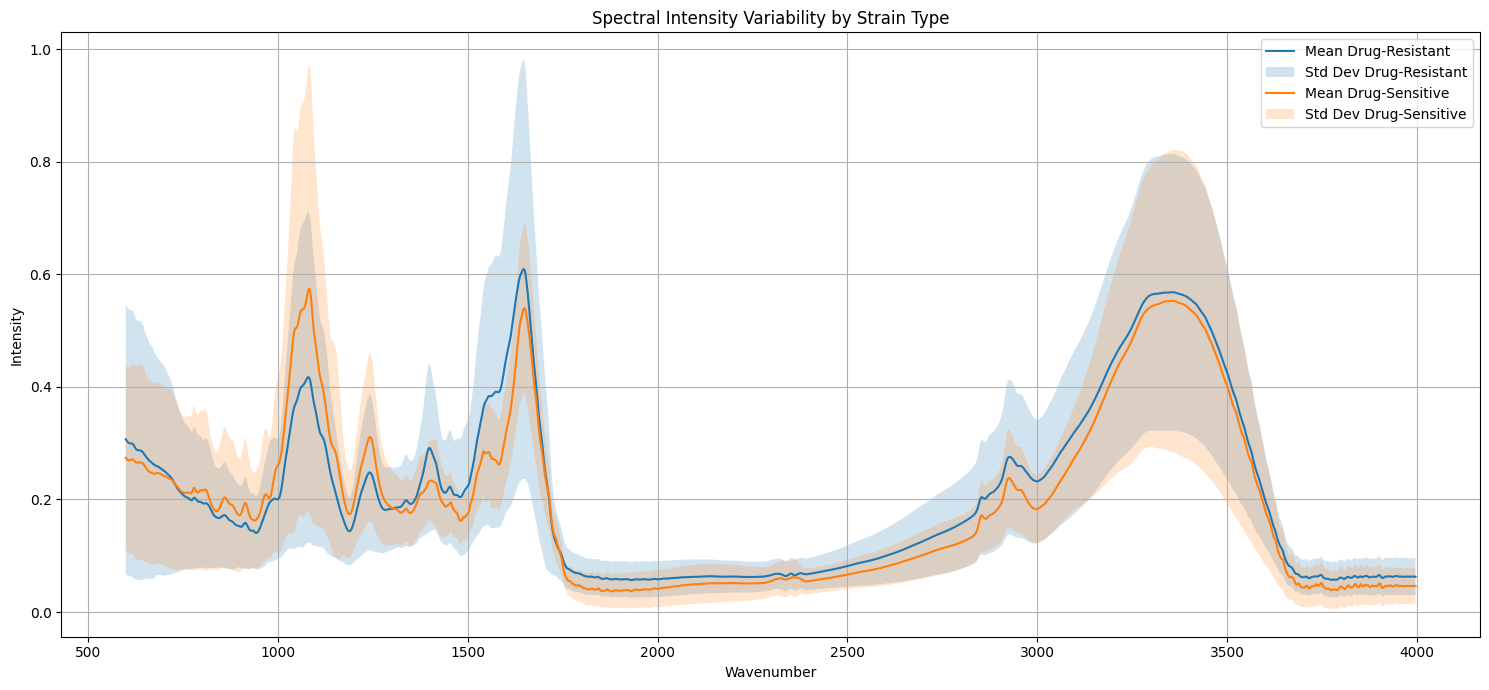

In [6]:
# Convert wavenumbers to numeric for plotting
wavenumbers = pd.to_numeric(spectral_columns)

plt.figure(figsize=(15, 7))

for strain_type in mean_spectra.index:
    mean_vals = mean_spectra.loc[strain_type]
    std_vals = std_spectra.loc[strain_type]

    plt.plot(wavenumbers, mean_vals, label=f'Mean {strain_type}')
    plt.fill_between(wavenumbers, mean_vals - std_vals, mean_vals + std_vals, alpha=0.2, label=f'Std Dev {strain_type}')

plt.title('Spectral Intensity Variability by Strain Type')
plt.xlabel('Wavenumber')
plt.ylabel('Intensity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Peak Analysis

We will now identify the most significant peaks in the mean spectra for each strain type. Peak detection helps in identifying the specific molecular vibrations (represented by wavenumbers) that contribute most to the spectral fingerprint.

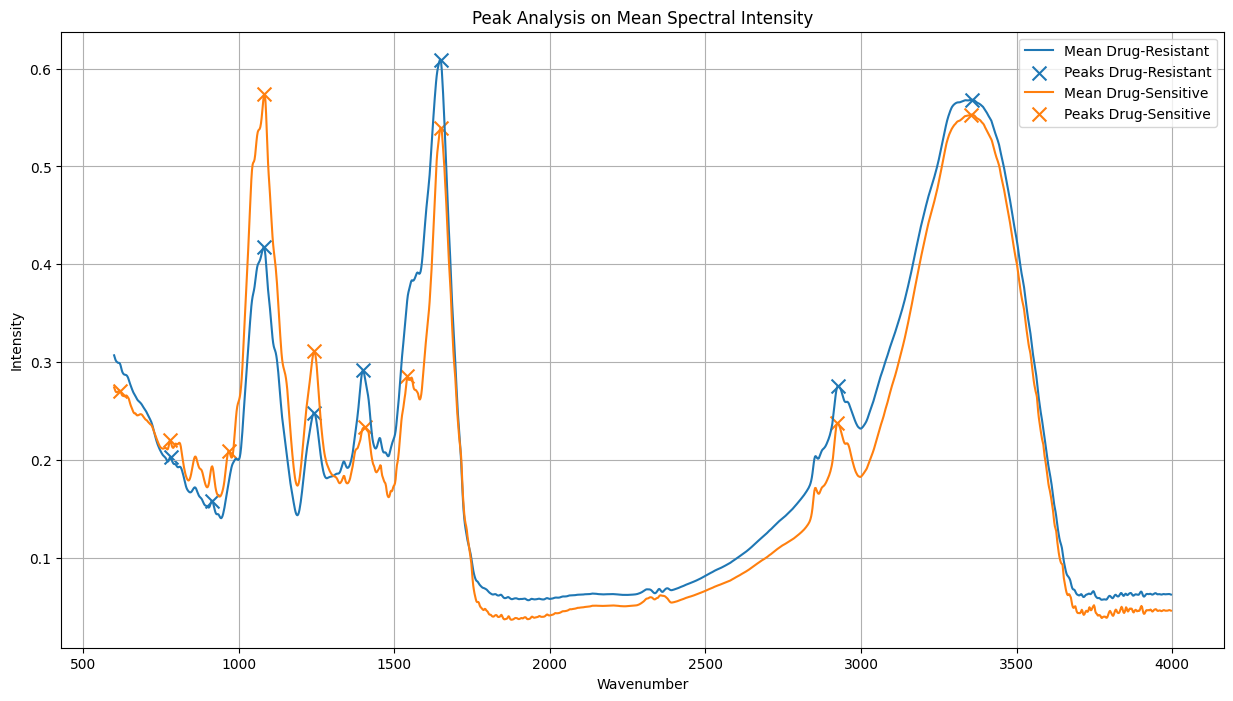


Top 5 Peaks for Drug-Resistant:


,Wavenumber,Intensity
2,1648.70,0.609087
0,3357.17,0.568217
5,1079.90,0.417332
3,1399.34,0.291633
1,2926.45,0.275647



Top 5 Peaks for Drug-Sensitive:


,Wavenumber,Intensity
6,1081.96,0.574113
0,3355.11,0.553048
2,1648.70,0.539590
5,1242.71,0.311154
3,1541.54,0.285574


In [26]:
from scipy.signal import find_peaks

plt.figure(figsize=(15, 8))

peak_info = {}

for strain_type in mean_spectra.index:
    mean_vals = mean_spectra.loc[strain_type].values
    # Find peaks with a minimum height and distance to filter noise
    peaks, properties = find_peaks(mean_vals, height=0.1, distance=50)

    # Map indices back to wavenumbers
    peak_wavenumbers = wavenumbers[peaks]
    peak_intensities = mean_vals[peaks]

    plt.plot(wavenumbers, mean_vals, label=f'Mean {strain_type}')
    plt.scatter(peak_wavenumbers, peak_intensities, marker='x', s=100, label=f'Peaks {strain_type}')

    # Store for display
    peak_info[strain_type] = pd.DataFrame({
        'Wavenumber': peak_wavenumbers,
        'Intensity': peak_intensities
    }).sort_values(by='Intensity', ascending=False)

plt.title('Peak Analysis on Mean Spectral Intensity')
plt.xlabel('Wavenumber')
plt.ylabel('Intensity')
plt.legend()
plt.grid(True)
plt.show()

for strain, info in peak_info.items():
    print(f"\nTop 5 Peaks for {strain}:")
    display(info.head(5))

### Statistical Analysis: T-Test on Key Peak Intensities

We will now use an independent t-test to determine if the observed differences in mean intensities at specific wavenumbers are statistically significant.

In [28]:
from scipy import stats

# The column names are floats, not strings.
# We convert our target peak wavenumbers to match the numeric type in df.columns.
peak1_wn = 1648.7
peak2_wn = 1081.96

# Find the closest actual column names in case of slight precision differences
actual_col1 = df.columns[np.abs(pd.to_numeric(df.columns, errors='coerce') - peak1_wn).argmin()]
actual_col2 = df.columns[np.abs(pd.to_numeric(df.columns, errors='coerce') - peak2_wn).argmin()]

print(f"Performing t-test on columns: {actual_col1} and {actual_col2}")

# Extract intensities for both groups
resistant_p1 = df[df['Strain_Type'] == 'Drug-Resistant'][actual_col1]
sensitive_p1 = df[df['Strain_Type'] == 'Drug-Sensitive'][actual_col1]

resistant_p2 = df[df['Strain_Type'] == 'Drug-Resistant'][actual_col2]
sensitive_p2 = df[df['Strain_Type'] == 'Drug-Sensitive'][actual_col2]

# Perform Independent T-Tests (Welch's t-test which doesn't assume equal variance)
t_stat1, p_val1 = stats.ttest_ind(resistant_p1, sensitive_p1, equal_var=False)
t_stat2, p_val2 = stats.ttest_ind(resistant_p2, sensitive_p2, equal_var=False)

# Results Summary
results = pd.DataFrame({
    'Peak Wavenumber': [actual_col1, actual_col2],
    'T-Statistic': [t_stat1, t_stat2],
    'P-Value': [p_val1, p_val2],
    'Significant (p < 0.05)': [p_val1 < 0.05, p_val2 < 0.05]
})

print("\nT-Test Results comparing Drug-Resistant vs Drug-Sensitive intensities:")
display(results)

Performing t-test on columns: 1648.7 and 1081.96

T-Test Results comparing Drug-Resistant vs Drug-Sensitive intensities:


,Peak Wavenumber,T-Statistic,P-Value,Significant (p < 0.05)
0,1648.70,1.168104,0.246698,False
1,1081.96,-1.857346,0.069692,False


### Plotting All Spectral Data by Original Labels

To see the full variance across the dataset, we will plot each sample individually using its original strain name from the 'Wavenumber' column as the label.

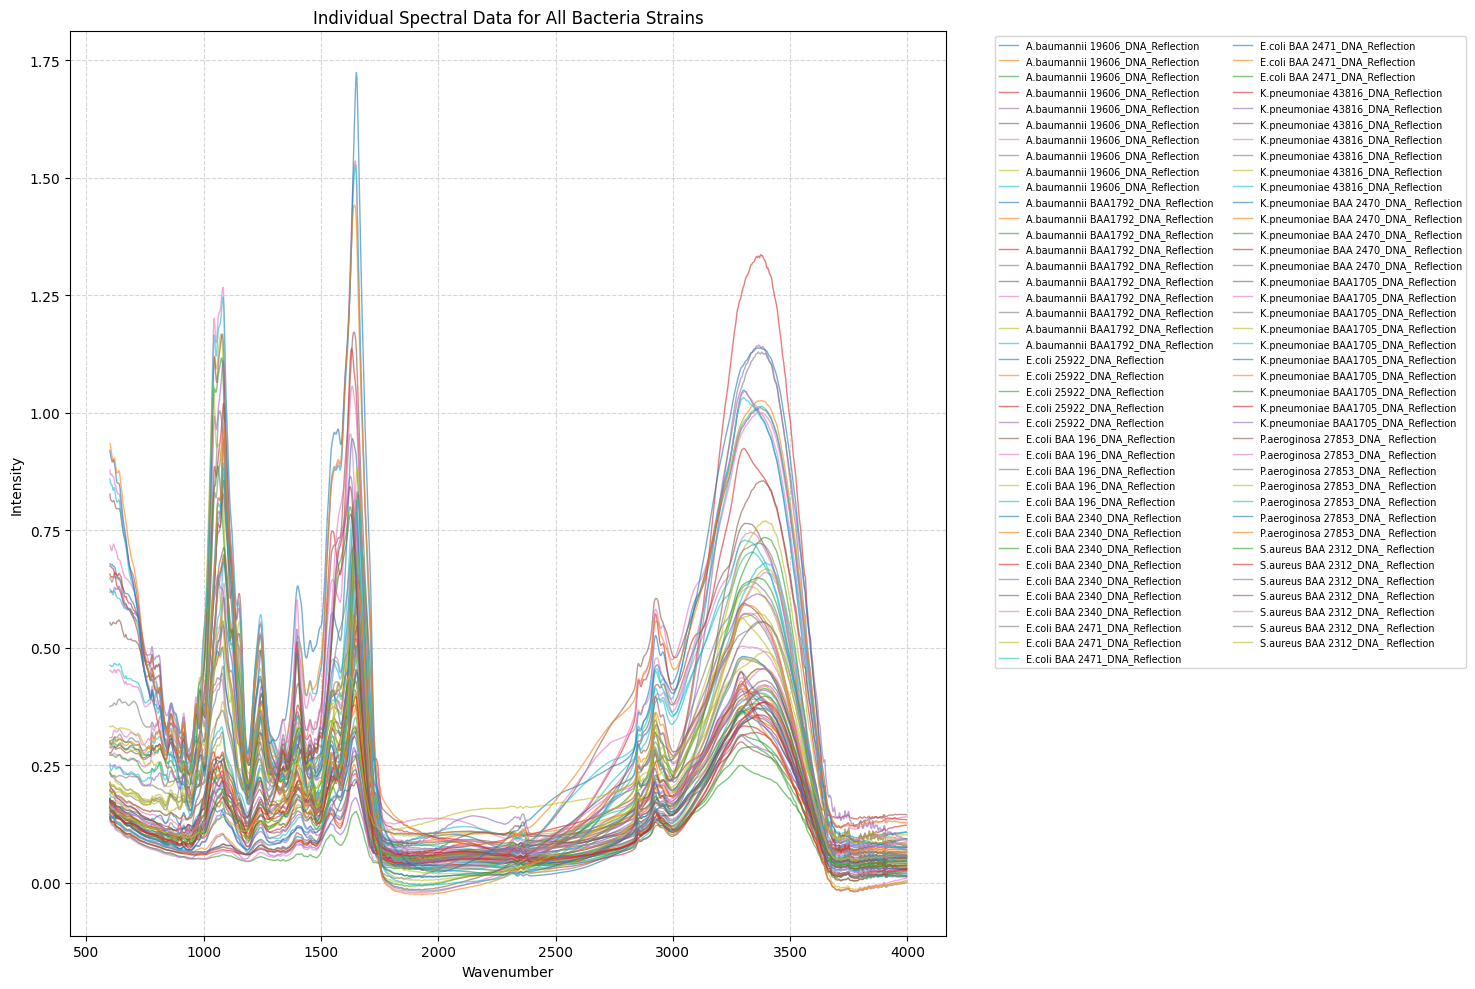

In [23]:
import matplotlib.pyplot as plt

# Prepare features and labels
# spectral_columns was defined previously as the numeric wavenumber columns
# df['Wavenumber'] contains the original strain names

plt.figure(figsize=(15, 10))

# Plot each row in the dataframe
for index, row in df.iterrows():
    plt.plot(wavenumbers, row[spectral_columns], label=row['Wavenumber'], alpha=0.6, linewidth=1)

plt.title('Individual Spectral Data for All Bacteria Strains')
plt.xlabel('Wavenumber')
plt.ylabel('Intensity')

# Since there are 79 strains, a standard legend will be too large.
# We'll place it outside the plot or skip it if it's too cluttered,
# but here we'll try to display it neatly to the side.
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small', ncol=2)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Spectral Data Variance Grouped by Strain Type

In this plot, all samples belonging to the same bacterial strain (as labeled in the original data) will share the same color. This helps visualize how much the intensity varies among identical samples versus different strains.

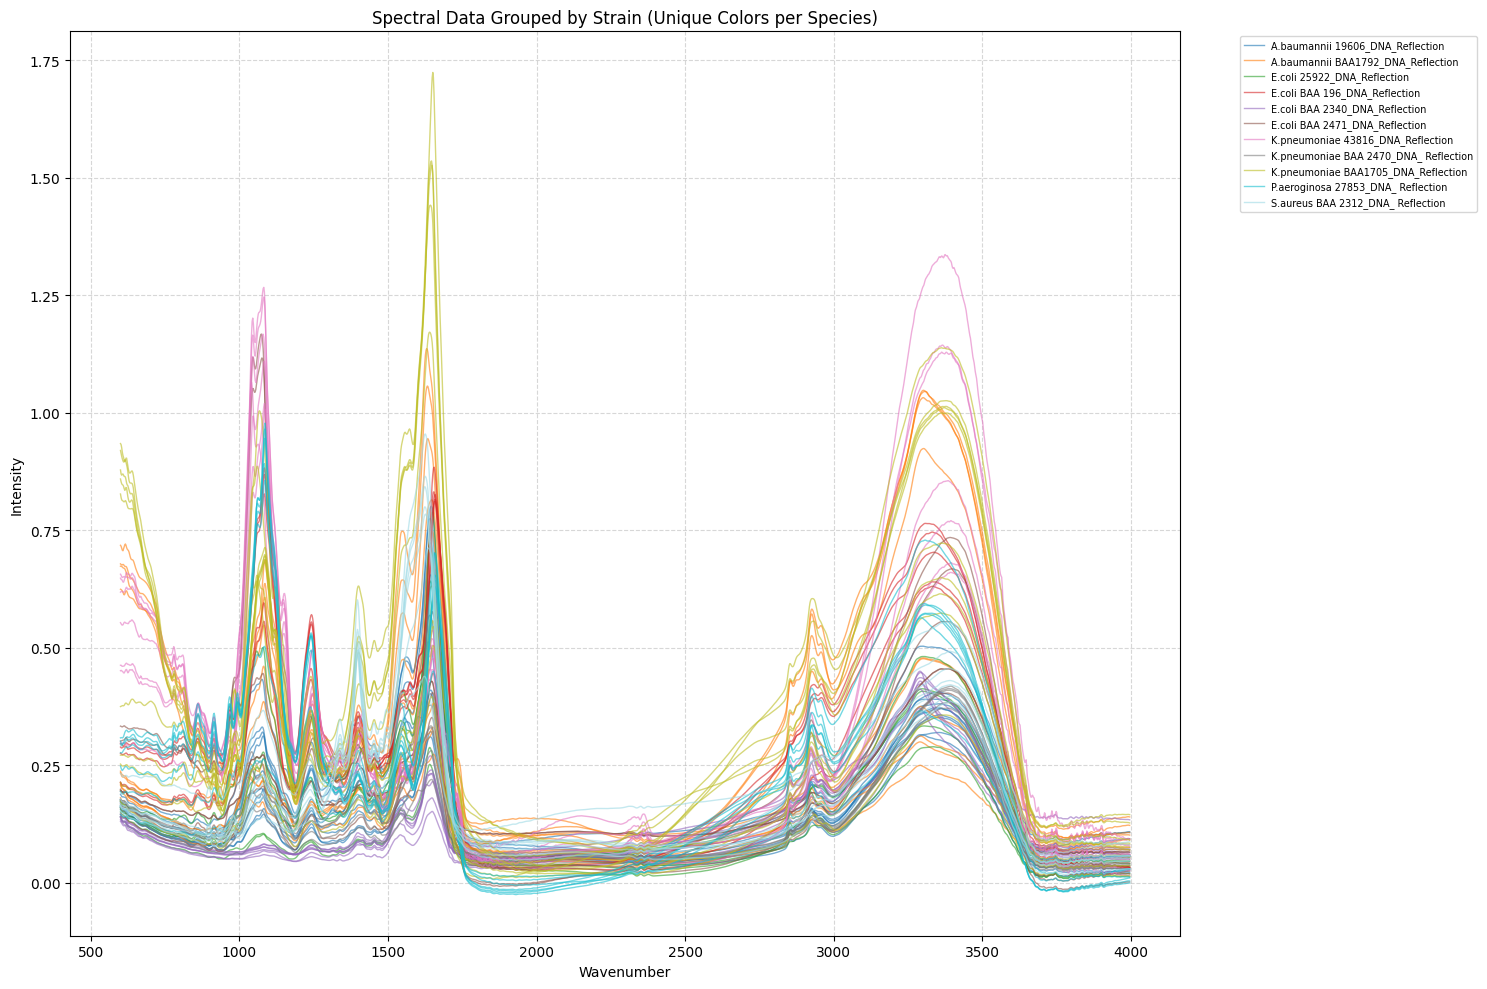

In [25]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Identify unique strains from the original 'Wavenumber' column
unique_strains = df['Wavenumber'].unique()
# Create a color map to assign a unique color to each strain using the modern API
colors = mpl.colormaps['tab20'].resampled(len(unique_strains))
strain_color_map = {strain: colors(i) for i, strain in enumerate(unique_strains)}

plt.figure(figsize=(15, 10))

# Track which labels have been added to the legend to avoid duplicates
added_labels = set()

for index, row in df.iterrows():
    strain_name = row['Wavenumber']
    label = strain_name if strain_name not in added_labels else ""

    plt.plot(wavenumbers, row[spectral_columns],
             color=strain_color_map[strain_name],
             label=label,
             alpha=0.6,
             linewidth=1)

    if strain_name not in added_labels:
        added_labels.add(strain_name)

plt.title('Spectral Data Grouped by Strain (Unique Colors per Species)')
plt.xlabel('Wavenumber')
plt.ylabel('Intensity')

# Display legend with unique strain names only
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small', ncol=1)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Principal Component Analysis (PCA)

Now, let's apply PCA to the spectral data to reduce its dimensionality and observe if the drug-resistant and drug-sensitive strains can be differentiated in a lower-dimensional space.

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Separate spectral data (features) from Wavenumber and Strain_Type
X = df[spectral_columns]
y = df['Strain_Type']

# Standardize the spectral data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape of scaled spectral data:", X_scaled.shape)


Shape of scaled spectral data: (79, 1649)


In [8]:
# Perform PCA with 2 components for visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# Create a DataFrame with the principal components
pca_df = pd.DataFrame(data=principal_components, columns=['Principal Component 1', 'Principal Component 2'])

# Add the Strain_Type back to the PCA DataFrame
pca_df['Strain_Type'] = y.reset_index(drop=True)

print("Explained variance ratio by the first two principal components:", pca.explained_variance_ratio_)
print("Cumulative explained variance ratio:", pca.explained_variance_ratio_.sum())
display(pca_df.head())


Explained variance ratio by the first two principal components: [0.5240282  0.23151045]
Cumulative explained variance ratio: 0.755538643640737


,Principal Component 1,Principal Component 2,Strain_Type
0,-27.640680,7.290637,Drug-Sensitive
1,-6.347839,30.142629,Drug-Sensitive
2,-27.789251,6.731511,Drug-Sensitive
3,-32.155230,-1.034812,Drug-Sensitive
4,-31.451311,2.625928,Drug-Sensitive


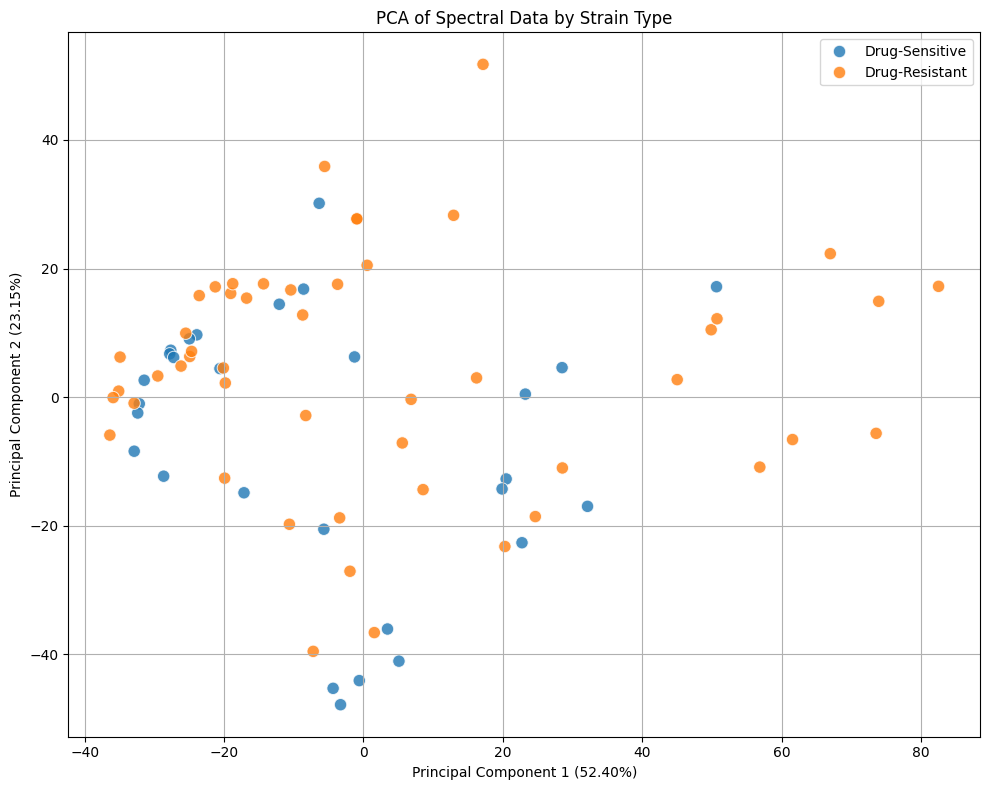

In [9]:
# Visualize the PCA results
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Strain_Type',
    data=pca_df,
    s=80,  # size of points
    alpha=0.8
)
plt.title('PCA of Spectral Data by Strain Type')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Determine Number of Principal Components for 95% Variance

Let's determine the optimal number of principal components needed to explain at least 95% of the total variance in the spectral data. This will help us understand the inherent dimensionality of the data while retaining most of its information.

In [10]:
# Perform PCA without limiting n_components to get all principal components
pca_full = PCA()
pca_full.fit(X_scaled)

# Calculate cumulative explained variance ratio
cum_var_ratio = np.cumsum(pca_full.explained_variance_ratio_)

# Find the number of components for 95% variance
num_components_95 = np.where(cum_var_ratio >= 0.95)[0][0] + 1

print(f"Number of principal components to explain 95% of variance: {num_components_95}")


Number of principal components to explain 95% of variance: 6


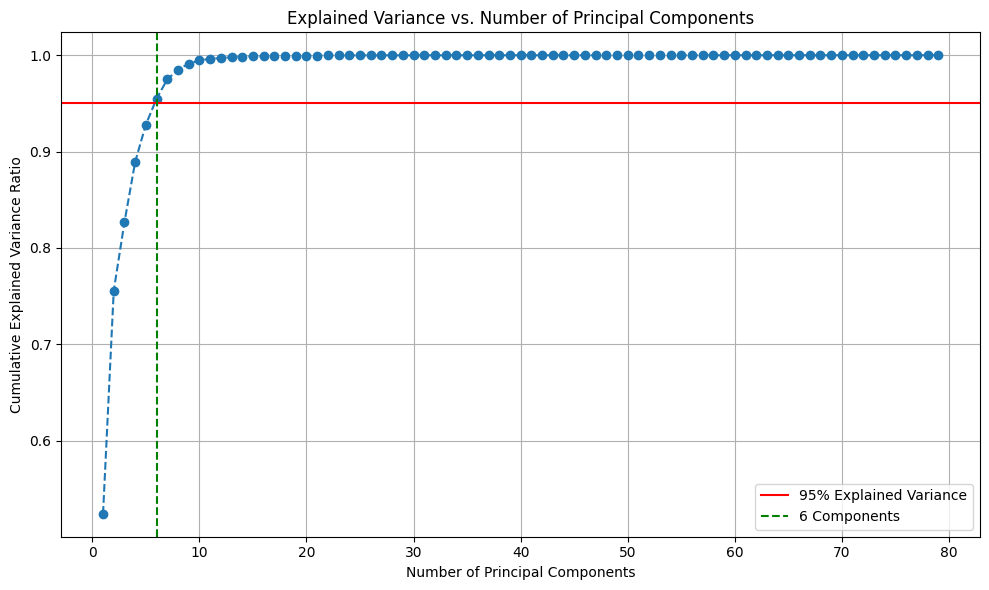

In [11]:
# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_var_ratio) + 1), cum_var_ratio, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance')
plt.axvline(x=num_components_95, color='g', linestyle='--', label=f'{num_components_95} Components')
plt.title('Explained Variance vs. Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### First Derivative Transformation and PCA Analysis

We will now apply a first derivative transformation to the spectral data. This often helps in enhancing small spectral features and reducing the impact of background baseline variations.

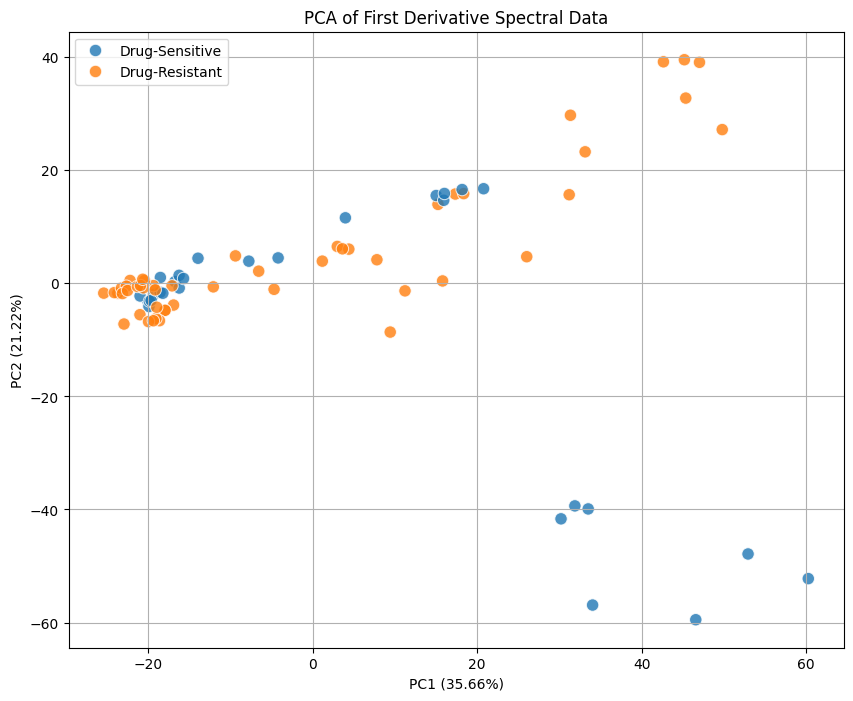

Total variance explained by first two components (Derivative): 56.88%


In [29]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Calculate the first derivative of the spectral columns
# We use np.gradient which is more robust than simple differencing
X_derivative = np.gradient(df[spectral_columns], axis=1)

# 2. Standardize the derivative data
scaler_der = StandardScaler()
X_der_scaled = scaler_der.fit_transform(X_derivative)

# 3. Perform PCA on the derivative data
pca_der = PCA(n_components=2)
principal_components_der = pca_der.fit_transform(X_der_scaled)

# Create a DataFrame for visualization
pca_der_df = pd.DataFrame(data=principal_components_der, columns=['PC1 (Derivative)', 'PC2 (Derivative)'])
pca_der_df['Strain_Type'] = df['Strain_Type'].values

# 4. Plotting
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1 (Derivative)',
    y='PC2 (Derivative)',
    hue='Strain_Type',
    data=pca_der_df,
    s=80,
    alpha=0.8
)

plt.title('PCA of First Derivative Spectral Data')
plt.xlabel(f'PC1 ({pca_der.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca_der.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.legend()
plt.show()

print(f"Total variance explained by first two components (Derivative): {pca_der.explained_variance_ratio_.sum()*100:.2f}%")

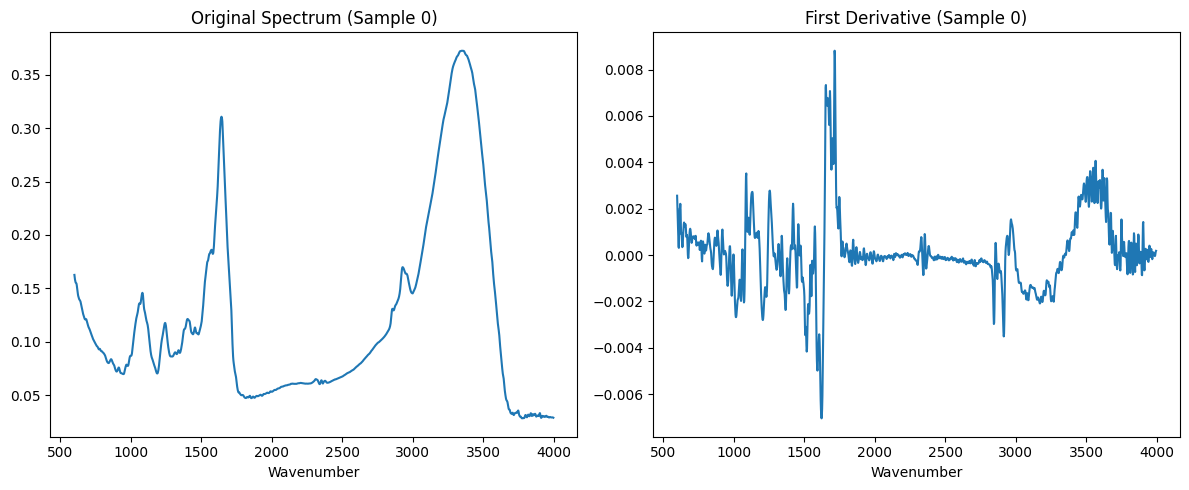

In [30]:
# Optional: Visualize what the derivative looks like for a single sample
plt.figure(figsize=(12, 5))
sample_idx = 0
plt.subplot(1, 2, 1)
plt.plot(wavenumbers, df[spectral_columns].iloc[sample_idx])
plt.title('Original Spectrum (Sample 0)')
plt.xlabel('Wavenumber')

plt.subplot(1, 2, 2)
plt.plot(wavenumbers, X_derivative[sample_idx])
plt.title('First Derivative (Sample 0)')
plt.xlabel('Wavenumber')

plt.tight_layout()
plt.show()

### Savitzky-Golay Smoothing

We will now apply Savitzky-Golay smoothing to the spectral data. This helps to reduce high-frequency noise while preserving the underlying signal and peak positions.

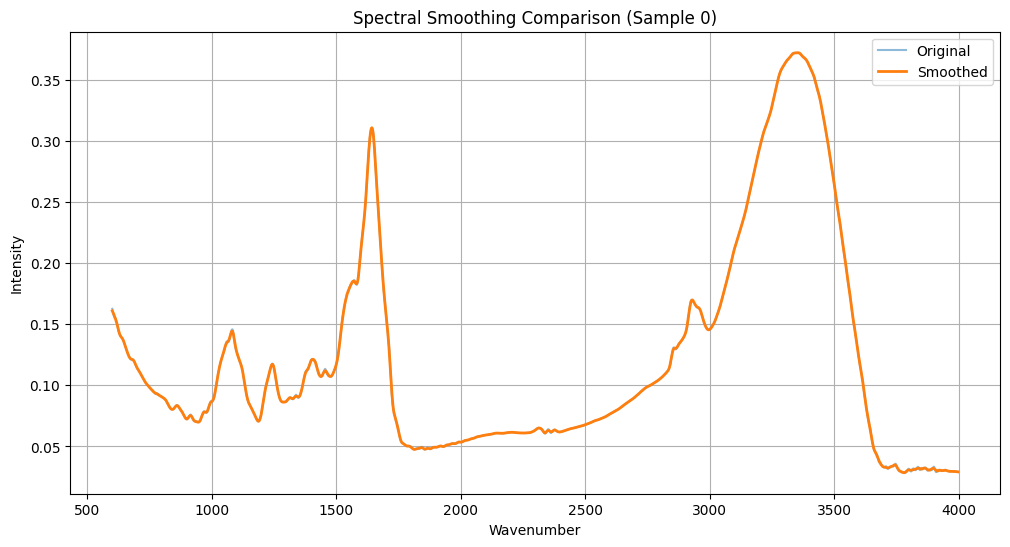

In [31]:
from scipy.signal import savgol_filter

# Apply Savitzky-Golay smoothing
# window_length: size of the filter window (must be odd)
# polyorder: order of the polynomial used to fit the samples
window_size = 15
poly_order = 2

df_smoothed = df.copy()
df_smoothed[spectral_columns] = savgol_filter(df[spectral_columns], window_length=window_size, polyorder=poly_order, axis=1)

# Visualize the effect of smoothing on the first sample
plt.figure(figsize=(12, 6))
sample_idx = 0
plt.plot(wavenumbers, df[spectral_columns].iloc[sample_idx], label='Original', alpha=0.5)
plt.plot(wavenumbers, df_smoothed[spectral_columns].iloc[sample_idx], label='Smoothed', linewidth=2)
plt.title(f'Spectral Smoothing Comparison (Sample {sample_idx})')
plt.xlabel('Wavenumber')
plt.ylabel('Intensity')
plt.legend()
plt.grid(True)
plt.show()

### PCA on Smoothed First Derivative Data

To further refine the features, we will now apply smoothing to the first derivative calculated earlier. This can help highlight meaningful peaks in the derivative while suppressing noise amplified by the differentiation process.

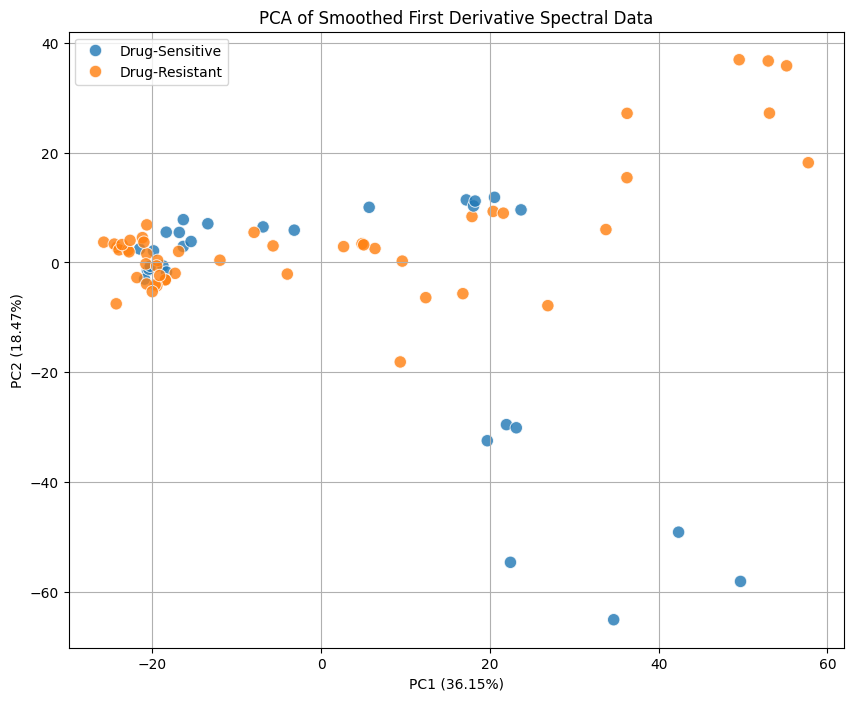

Total variance explained by first two components (Smoothed Derivative): 54.62%


In [33]:
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Smoothen the first derivative data (X_derivative was calculated in cell 29c798a7)
X_der_smoothed = savgol_filter(X_derivative, window_length=15, polyorder=2, axis=1)

# 2. Standardize the smoothed derivative data
scaler_der_smooth = StandardScaler()
X_der_smooth_scaled = scaler_der_smooth.fit_transform(X_der_smoothed)

# 3. Perform PCA with 2 components
pca_der_smooth = PCA(n_components=2)
principal_components_der_smooth = pca_der_smooth.fit_transform(X_der_smooth_scaled)

# 4. Create a DataFrame for visualization
pca_der_smooth_df = pd.DataFrame(data=principal_components_der_smooth, columns=['PC1 (Deriv+Smooth)', 'PC2 (Deriv+Smooth)'])
pca_der_smooth_df['Strain_Type'] = df['Strain_Type'].values

# 5. Plotting
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1 (Deriv+Smooth)',
    y='PC2 (Deriv+Smooth)',
    hue='Strain_Type',
    data=pca_der_smooth_df,
    s=80,
    alpha=0.8
)

plt.title('PCA of Smoothed First Derivative Spectral Data')
plt.xlabel(f'PC1 ({pca_der_smooth.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca_der_smooth.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.legend()
plt.show()

print(f"Total variance explained by first two components (Smoothed Derivative): {pca_der_smooth.explained_variance_ratio_.sum()*100:.2f}%")

### PCA on Smoothed Second Derivative Data

Moving to the second derivative can help highlight changes in the curvature of the spectral peaks, which might contain diagnostic information for distinguishing drug-resistant strains. We will apply smoothing again as each derivative step increases the high-frequency noise.

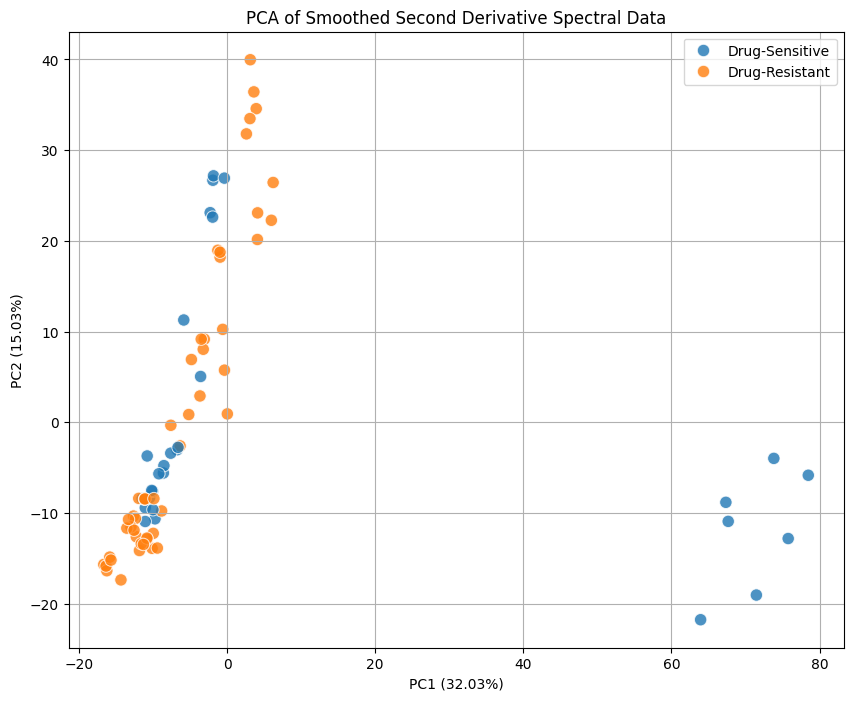

Total variance explained by first two components (Smoothed 2nd Derivative): 47.07%


In [34]:
import numpy as np
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Calculate the second derivative of the spectral columns
# We apply np.gradient twice
X_second_derivative = np.gradient(np.gradient(df[spectral_columns], axis=1), axis=1)

# 2. Smoothen the second derivative data
# Using the same window and polyorder as previous steps for consistency
X_2nd_der_smoothed = savgol_filter(X_second_derivative, window_length=15, polyorder=2, axis=1)

# 3. Standardize the smoothed second derivative data
scaler_2nd_der = StandardScaler()
X_2nd_der_scaled = scaler_2nd_der.fit_transform(X_2nd_der_smoothed)

# 4. Perform PCA with 2 components
pca_2nd_der = PCA(n_components=2)
principal_components_2nd_der = pca_2nd_der.fit_transform(X_2nd_der_scaled)

# 5. Create a DataFrame for visualization
pca_2nd_der_df = pd.DataFrame(data=principal_components_2nd_der, columns=['PC1 (2nd Deriv+Smooth)', 'PC2 (2nd Deriv+Smooth)'])
pca_2nd_der_df['Strain_Type'] = df['Strain_Type'].values

# 6. Plotting
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1 (2nd Deriv+Smooth)',
    y='PC2 (2nd Deriv+Smooth)',
    hue='Strain_Type',
    data=pca_2nd_der_df,
    s=80,
    alpha=0.8
)

plt.title('PCA of Smoothed Second Derivative Spectral Data')
plt.xlabel(f'PC1 ({pca_2nd_der.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca_2nd_der.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.legend()
plt.show()

print(f"Total variance explained by first two components (Smoothed 2nd Derivative): {pca_2nd_der.explained_variance_ratio_.sum()*100:.2f}%")

### Classification on Smoothed Second Derivative Data

We will now use the 6 principal components derived from the smoothed second derivative data to train a Random Forest model. This will help us determine if the curvature of the peaks provides better discriminative power than the raw intensities or first derivative.

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

# 1. Use the scaled smoothed second derivative data (already calculated)
# X_2nd_der_scaled from cell 0110bced

# 2. Perform PCA with 6 components
pca_2nd_6 = PCA(n_components=6)
X_pca_2nd = pca_2nd_6.fit_transform(X_2nd_der_scaled)

# 3. Split the data
X_train_2nd, X_test_2nd, y_train_2nd, y_test_2nd = train_test_split(
    X_pca_2nd, y, test_size=0.3, random_state=42
)

# 4. Balance with SMOTE
smote_2nd = SMOTE(random_state=42)
X_res_2nd, y_res_2nd = smote_2nd.fit_resample(X_train_2nd, y_train_2nd)

# 5. Train Random Forest (using previously found best parameters for consistency)
rf_2nd = RandomForestClassifier(n_estimators=50, bootstrap=False, random_state=42)
rf_2nd.fit(X_res_2nd, y_res_2nd)

# 6. Evaluate
y_pred_2nd = rf_2nd.predict(X_test_2nd)
print(f"Random Forest Accuracy on Smoothed 2nd Derivative: {accuracy_score(y_test_2nd, y_pred_2nd):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_2nd, y_pred_2nd))

print(f"Total variance explained by 6 components: {pca_2nd_6.explained_variance_ratio_.sum()*100:.2f}%")

Random Forest Accuracy on Smoothed 2nd Derivative: 0.9167

Classification Report:
                precision    recall  f1-score   support

Drug-Resistant       0.87      1.00      0.93        13
Drug-Sensitive       1.00      0.82      0.90        11

      accuracy                           0.92        24
     macro avg       0.93      0.91      0.91        24
  weighted avg       0.93      0.92      0.92        24

Total variance explained by 6 components: 70.29%


### Robustness Check: Leave-One-Out Cross-Validation (LOOCV)

Given the small sample size, we want to ensure our 91.67% accuracy isn't just a result of a favorable train-test split. LOOCV trains the model N times, each time using N-1 samples for training and the remaining 1 sample for testing.

In [36]:
from sklearn.model_selection import LeaveOneOut, cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline

# Define the pipeline to ensure SMOTE is only applied to training folds
loocv_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=50, bootstrap=False, random_state=42))
])

# Define LOOCV strategy
loo = LeaveOneOut()

# Run cross-validation
# We use the X_pca_2nd (6 components) and the full y series
scores = cross_val_score(loocv_pipeline, X_pca_2nd, y, cv=loo, scoring='accuracy', n_jobs=-1)

print(f"Average LOOCV Accuracy: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")

Average LOOCV Accuracy: 0.9620
Standard Deviation: 0.1911


### Statistical Variability Across Species

We will now shift focus from drug resistance to the inherent differences between bacterial species. We'll extract the species name from the labels and use ANOVA to test for significant differences in their spectral signatures.

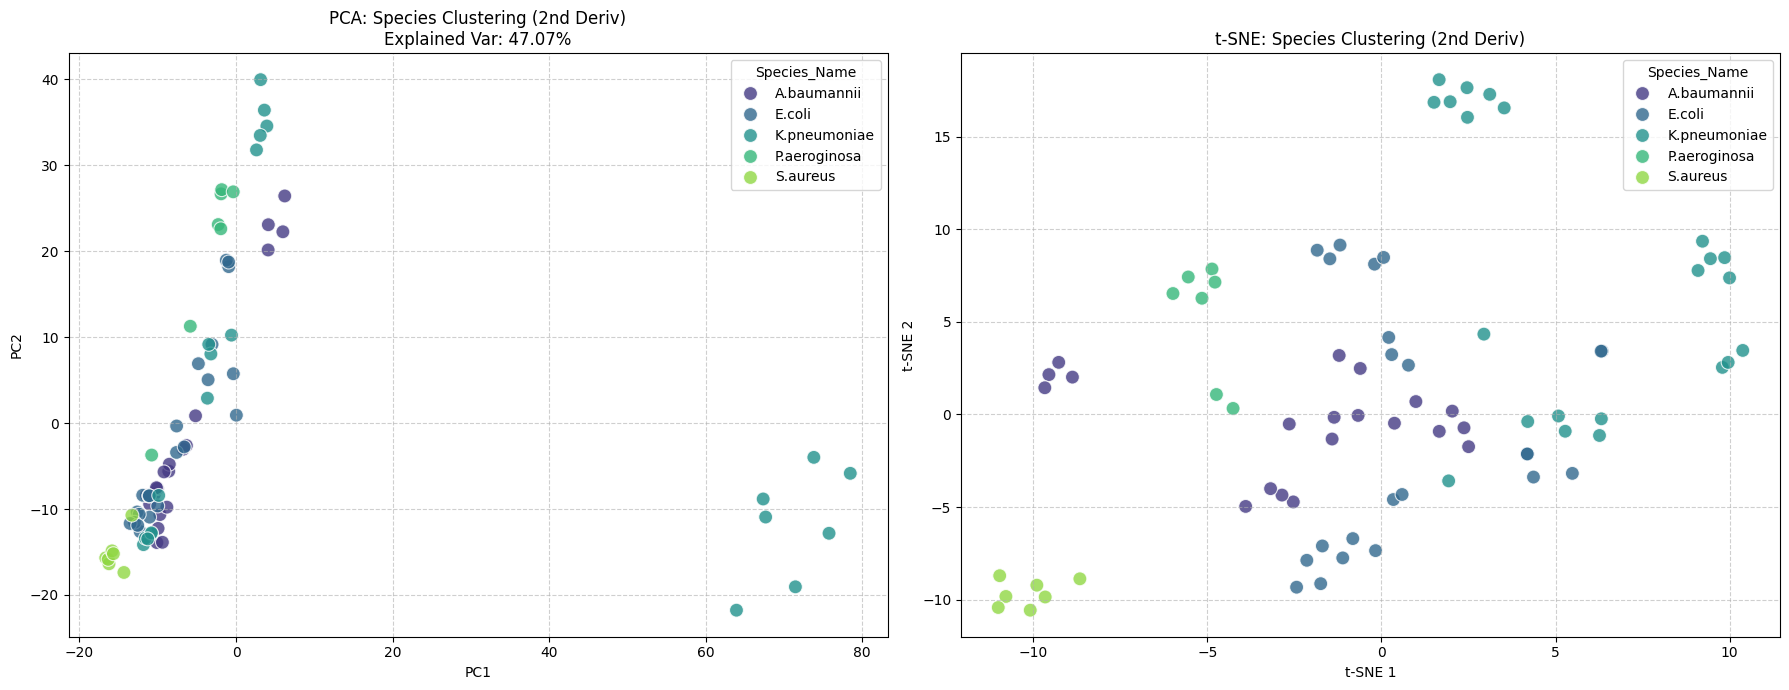

Unique species identified: ['A.baumannii' 'E.coli' 'K.pneumoniae' 'P.aeroginosa' 'S.aureus']


In [39]:
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# 1. Extract species names if not already present
def extract_species(name):
    match = re.search(r'^([A-Z]\.[a-z]+)', str(name))
    return match.group(1) if match else 'Unknown'

df['Species_Name'] = df['Wavenumber'].apply(extract_species)

# 2. Use the smoothed second derivative data (X_2nd_der_scaled was calculated in cell 0110bced)
# This data is already standardized. We will use it for PCA and t-SNE.

# --- PCA Analysis ---
pca_species = PCA(n_components=2)
pca_results = pca_species.fit_transform(X_2nd_der_scaled)

# --- t-SNE Analysis ---
tsne_species = TSNE(n_components=2, perplexity=15, random_state=42, init='pca', learning_rate='auto')
tsne_results = tsne_species.fit_transform(X_2nd_der_scaled)

# 3. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot PCA
sns.scatterplot(
    x=pca_results[:, 0], y=pca_results[:, 1],
    hue=df['Species_Name'], palette='viridis', s=100, alpha=0.8, ax=ax1
)
ax1.set_title(f'PCA: Species Clustering (2nd Deriv)\nExplained Var: {pca_species.explained_variance_ratio_.sum()*100:.2f}%')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot t-SNE
sns.scatterplot(
    x=tsne_results[:, 0], y=tsne_results[:, 1],
    hue=df['Species_Name'], palette='viridis', s=100, alpha=0.8, ax=ax2
)
ax2.set_title('t-SNE: Species Clustering (2nd Deriv)')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("Unique species identified:", df['Species_Name'].unique())

In [38]:
from scipy.stats import f_oneway

# Perform One-Way ANOVA for the top peaks identified earlier across species
peaks_to_test = [actual_col1, actual_col2]
anova_results = []

for peak in peaks_to_test:
    groups = [group[peak].values for name, group in df.groupby('Species_Name')]
    f_stat, p_val = f_oneway(*groups)
    anova_results.append({
        'Wavenumber': peak,
        'F-Statistic': f_stat,
        'P-Value': p_val,
        'Significant (p < 0.05)': p_val < 0.05
    })

anova_df = pd.DataFrame(anova_results)
print("ANOVA Results: Differences across Species")
display(anova_df)

ANOVA Results: Differences across Species


,Wavenumber,F-Statistic,P-Value,Significant (p < 0.05)
0,1648.70,1.439527,0.229463,False
1,1081.96,7.464967,0.000042,True


### Comprehensive Spectral ANOVA

To move beyond the two peaks tested earlier, we will now perform a One-Way ANOVA for every wavenumber in the dataset to identify all regions where intensities differ significantly between species.

In [40]:
from scipy.stats import f_oneway

# Perform ANOVA for all spectral columns
all_anova_results = []
for col in spectral_columns:
    groups = [group[col].values for name, group in df.groupby('Species_Name')]
    f_stat, p_val = f_oneway(*groups)
    all_anova_results.append({'Wavenumber': float(col), 'p_value': p_val, 'f_stat': f_stat})

anova_full_df = pd.DataFrame(all_anova_results)
anova_full_df['-log10(p)'] = -np.log10(anova_full_df['p_value'])

# Identify top 10 most significant wavenumbers
top_10_diff = anova_full_df.sort_values(by='f_stat', ascending=False).head(10)
print("Top 10 Wavenumbers with Most Significant Differences Across Species:")
display(top_10_diff)

Top 10 Wavenumbers with Most Significant Differences Across Species:


,Wavenumber,p_value,f_stat,-log10(p)
999,1937.23,1.964270e-09,15.893847,8.706799
993,1949.59,1.970557e-09,15.890785,8.705411
994,1947.53,1.986308e-09,15.883160,8.701953
1000,1935.17,1.996180e-09,15.878411,8.699800
998,1939.29,1.996398e-09,15.878307,8.699753
992,1951.65,1.998808e-09,15.877152,8.699229
1001,1933.11,2.032571e-09,15.861115,8.691954
1003,1928.98,2.033758e-09,15.860556,8.691701
1004,1926.92,2.036807e-09,15.859122,8.691050
1002,1931.04,2.040956e-09,15.857174,8.690166


### Visualizing Significant Regions

We will plot the $-\log_{10}(p)$ values across the spectrum. Higher peaks in this plot indicate regions where the bacterial species are most distinct.

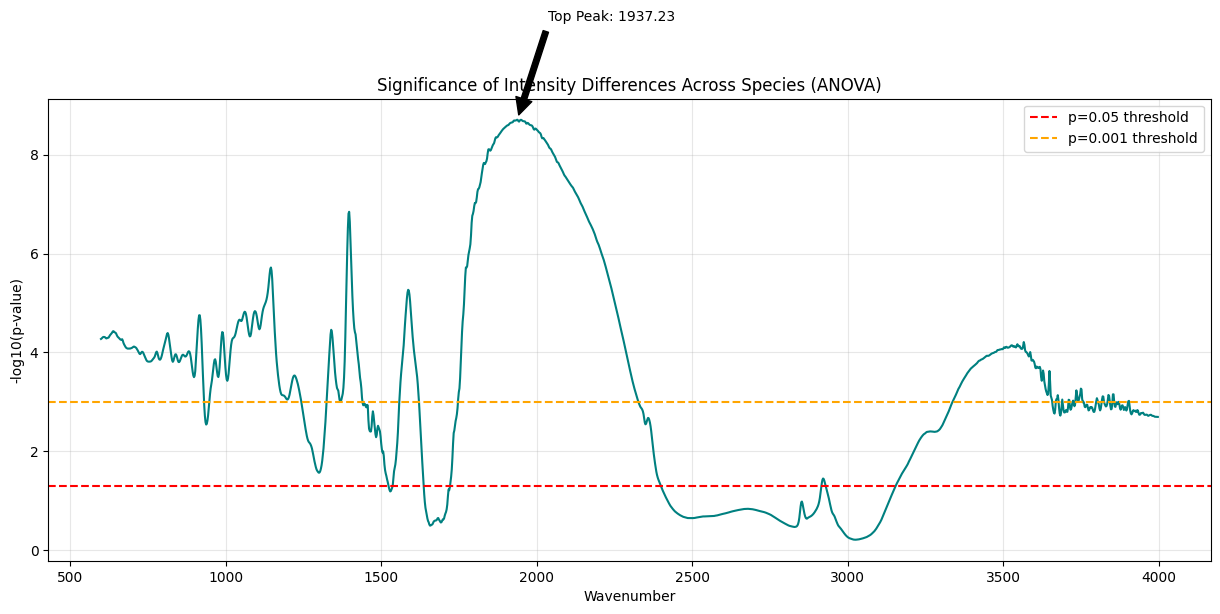

In [41]:
plt.figure(figsize=(15, 6))
plt.plot(anova_full_df['Wavenumber'], anova_full_df['-log10(p)'], color='teal')
plt.axhline(y=-np.log10(0.05), color='red', linestyle='--', label='p=0.05 threshold')
plt.axhline(y=-np.log10(0.001), color='orange', linestyle='--', label='p=0.001 threshold')

# Annotate the top peak
top_peak = top_10_diff.iloc[0]
plt.annotate(f"Top Peak: {top_peak['Wavenumber']:.2f}",
             xy=(top_peak['Wavenumber'], top_peak['-log10(p)']),
             xytext=(top_peak['Wavenumber']+100, top_peak['-log10(p)']+2),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title('Significance of Intensity Differences Across Species (ANOVA)')
plt.xlabel('Wavenumber')
plt.ylabel('-log10(p-value)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Post-hoc Analysis: Tukey's HSD

While ANOVA tells us that differences exist, Tukey's HSD test allows us to determine which specific species pairs are statistically different at the identified peaks.

In [43]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Get the most significant wavenumber from the ANOVA results
top_wavenumber = top_10_diff.iloc[0]['Wavenumber']
top_col = str(top_wavenumber)

# Perform Tukey's HSD
tukey = pairwise_tukeyhsd(endog=df[top_col], groups=df['Species_Name'], alpha=0.05)

print(f"Tukey HSD Results for Wavenumber: {top_wavenumber}")
print(tukey.summary())

# Visualize the pairwise differences
tukey.plot_simultaneous(xlabel='Intensity', ylabel='Species')
plt.title(f'Species Comparisons at {top_wavenumber} cm⁻¹')
plt.show()

KeyError: '1937.23'

### Post-hoc Analysis: Tukey's HSD

To determine which specific species differ at the most significant peak identified by ANOVA, we will perform Tukey's Honest Significant Difference (HSD) test.

Performing Tukey HSD on column: 1937.23 (Closest to 1937.23)

Tukey HSD Results Summary:
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
 A.baumannii       E.coli  -0.0256 0.0098 -0.0467 -0.0044   True
 A.baumannii K.pneumoniae  -0.0195 0.0895 -0.0409  0.0018  False
 A.baumannii P.aeroginosa  -0.0784    0.0 -0.1088 -0.0481   True
 A.baumannii     S.aureus   0.0101 0.8834 -0.0202  0.0405  False
      E.coli K.pneumoniae    0.006 0.9236 -0.0146  0.0267  False
      E.coli P.aeroginosa  -0.0528    0.0 -0.0827  -0.023   True
      E.coli     S.aureus   0.0357  0.011  0.0059  0.0655   True
K.pneumoniae P.aeroginosa  -0.0589    0.0 -0.0889 -0.0289   True
K.pneumoniae     S.aureus   0.0296 0.0544 -0.0004  0.0597  False
P.aeroginosa     S.aureus   0.0885    0.0  0.0516  0.1255   True
----------------------------------------------------------------


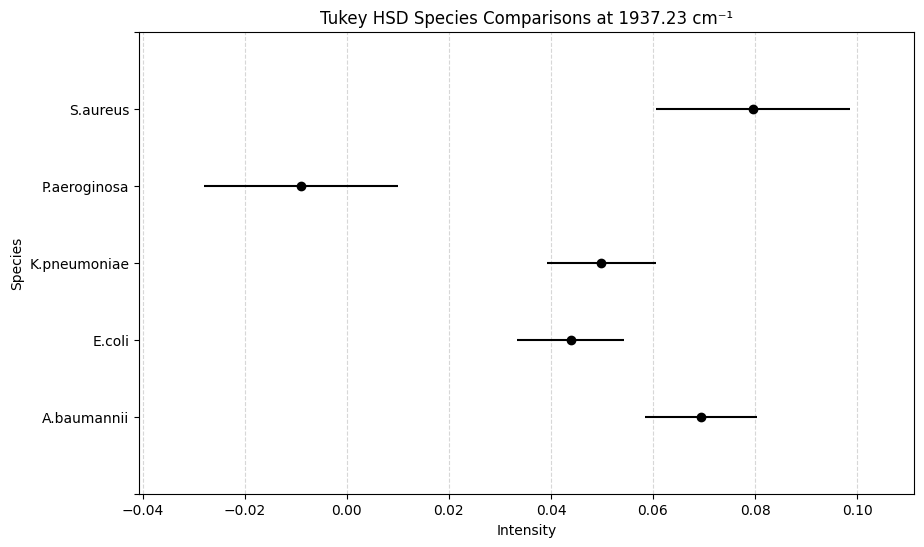

In [53]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. Safely identify the top wavenumber column
# We convert column names to numeric to find the closest match to the ANOVA top result
numeric_cols = pd.to_numeric(df.columns, errors='coerce')
top_wn_value = top_10_diff.iloc[0]['Wavenumber']
closest_col_idx = np.abs(numeric_cols - top_wn_value).argmin()
actual_top_col = df.columns[closest_col_idx]

print(f"Performing Tukey HSD on column: {actual_top_col} (Closest to {top_wn_value:.2f})")

# 2. Perform Tukey's HSD test
tukey = pairwise_tukeyhsd(endog=df[actual_top_col],
                          groups=df['Species_Name'],
                          alpha=0.05)

print("\nTukey HSD Results Summary:")
print(tukey.summary())

# 3. Visualize the results
tukey.plot_simultaneous(xlabel='Intensity', ylabel='Species')
plt.title(f'Tukey HSD Species Comparisons at {actual_top_col} cm⁻¹')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.show()

### Taxonomic Classification using 2nd Derivative Data

We will now use the smoothed second-derivative data to train a classifier for species identification. We will reduce the high-dimensional derivative data using PCA before applying a Random Forest model.

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. Use the pre-calculated smoothed second derivative data (X_2nd_der_scaled)
# 2. Apply PCA to keep 95% of the variance specifically for species classification
pca_species_95 = PCA(n_components=0.95)
X_pca_species = pca_species_95.fit_transform(X_2nd_der_scaled)

# 3. Split the data into training and testing sets based on Species_Name
y_species = df['Species_Name']
X_train_sp, X_test_sp, y_train_sp, y_test_sp = train_test_split(
    X_pca_species, y_species, test_size=0.3, random_state=42, stratify=y_species
)

# 4. Train a Random Forest Classifier
rf_species = RandomForestClassifier(n_estimators=100, random_state=42)
rf_species.fit(X_train_sp, y_train_sp)

# 5. Evaluate the model
y_pred_sp = rf_species.predict(X_test_sp)
accuracy_sp = accuracy_score(y_test_sp, y_pred_sp)

print(f"Number of Principal Components used: {X_pca_species.shape[1]}")
print(f"Species Classification Accuracy (2nd Deriv): {accuracy_sp:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test_sp, y_pred_sp))

Number of Principal Components used: 40
Species Classification Accuracy (2nd Deriv): 0.9583

Detailed Classification Report:
              precision    recall  f1-score   support

 A.baumannii       1.00      0.83      0.91         6
      E.coli       0.88      1.00      0.93         7
K.pneumoniae       1.00      1.00      1.00         7
P.aeroginosa       1.00      1.00      1.00         2
    S.aureus       1.00      1.00      1.00         2

    accuracy                           0.96        24
   macro avg       0.97      0.97      0.97        24
weighted avg       0.96      0.96      0.96        24



### Unified Taxonomic and Drug Sensitivity Classification

We will now combine `Species_Name` and `Strain_Type` into a single multi-class target variable, `Combined_Target`. We will use the same 40 principal components from the smoothed second-derivative data to train a model capable of predicting both species and resistance status simultaneously.

Unified Model Accuracy: 0.8750

Combined Classification Report:
                             precision    recall  f1-score   support

 A.baumannii_Drug-Resistant       0.67      0.67      0.67         3
 A.baumannii_Drug-Sensitive       1.00      1.00      1.00         3
      E.coli_Drug-Resistant       0.83      1.00      0.91         5
      E.coli_Drug-Sensitive       1.00      1.00      1.00         2
K.pneumoniae_Drug-Resistant       0.80      0.80      0.80         5
K.pneumoniae_Drug-Sensitive       1.00      1.00      1.00         2
P.aeroginosa_Drug-Sensitive       1.00      1.00      1.00         2
    S.aureus_Drug-Resistant       1.00      0.50      0.67         2

                   accuracy                           0.88        24
                  macro avg       0.91      0.87      0.88        24
               weighted avg       0.88      0.88      0.87        24



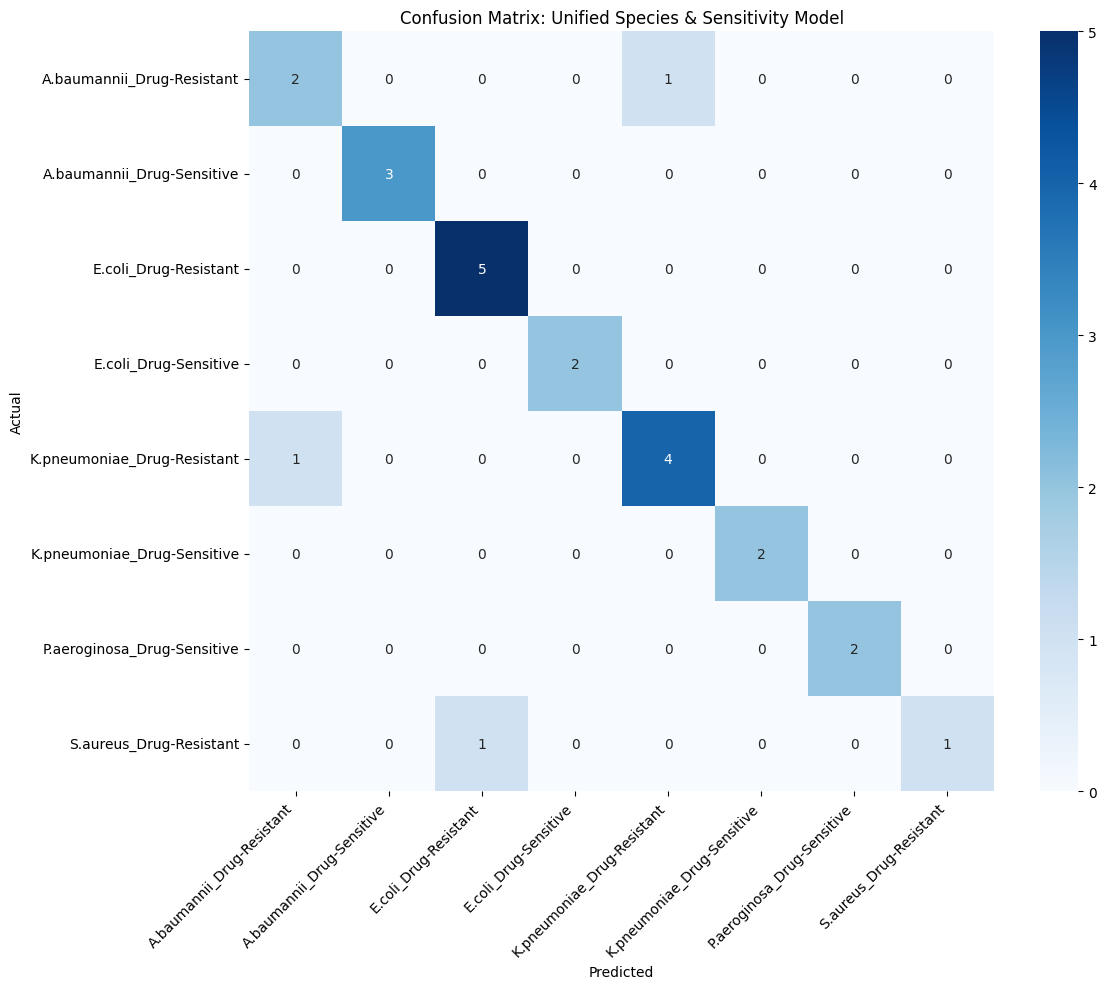

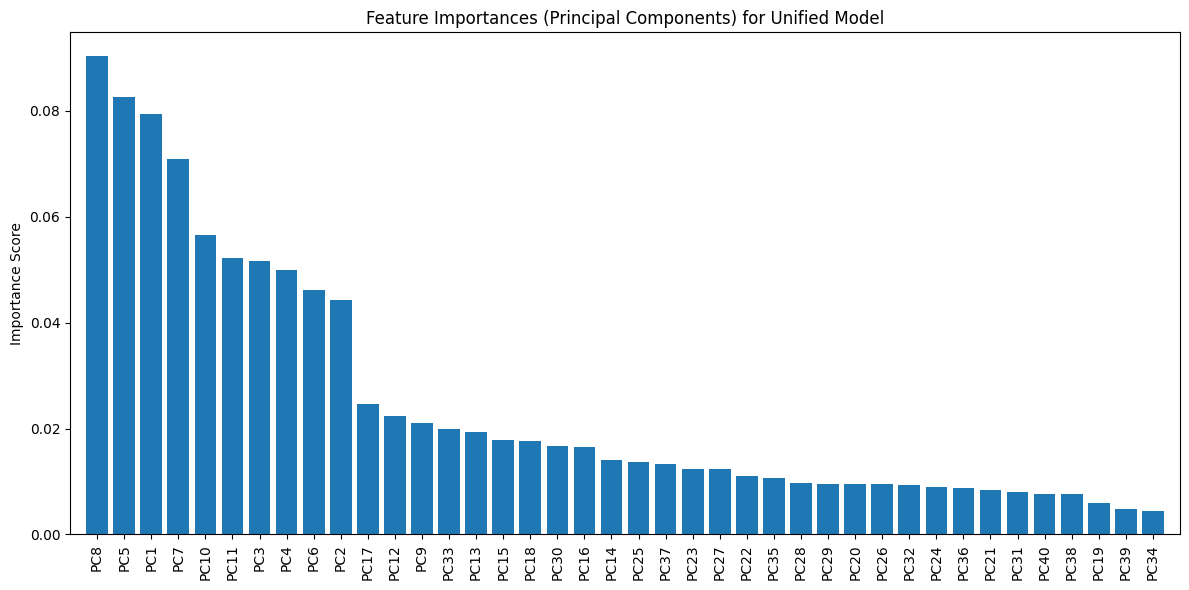

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the combined target variable
df['Combined_Target'] = df['Species_Name'] + '_' + df['Strain_Type']
y_combined = df['Combined_Target']

# 2. Use the existing 40 PC features from the 2nd derivative (X_pca_species)
X_train_com, X_test_com, y_train_com, y_test_com = train_test_split(
    X_pca_species, y_combined, test_size=0.3, random_state=42, stratify=y_combined
)

# 3. Train the Unified Random Forest Model
rf_combined = RandomForestClassifier(n_estimators=150, random_state=42, bootstrap=False)
rf_combined.fit(X_train_com, y_train_com)

# 4. Evaluate
y_pred_com = rf_combined.predict(X_test_com)
accuracy_com = accuracy_score(y_test_com, y_pred_com)

print(f"Unified Model Accuracy: {accuracy_com:.4f}")
print("\nCombined Classification Report:")
print(classification_report(y_test_com, y_pred_com))

# 5. Visualize Confusion Matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test_com, y_pred_com, labels=sorted(y_combined.unique()))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_combined.unique()),
            yticklabels=sorted(y_combined.unique()))
plt.title('Confusion Matrix: Unified Species & Sensitivity Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 6. Feature Importance Analysis
importances = rf_combined.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances (Principal Components) for Unified Model")
plt.bar(range(X_train_com.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train_com.shape[1]), [f'PC{i+1}' for i in indices], rotation=90)
plt.xlim([-1, X_train_com.shape[1]])
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

### Unsupervised Clustering: K-Means on 2nd Derivative PCA

We will use K-Means clustering to see if the data naturally separates into groups that correspond to drug resistance status across species. We'll use the same 6 Principal Components (X_pca_2nd) that provided high accuracy in our classification models.

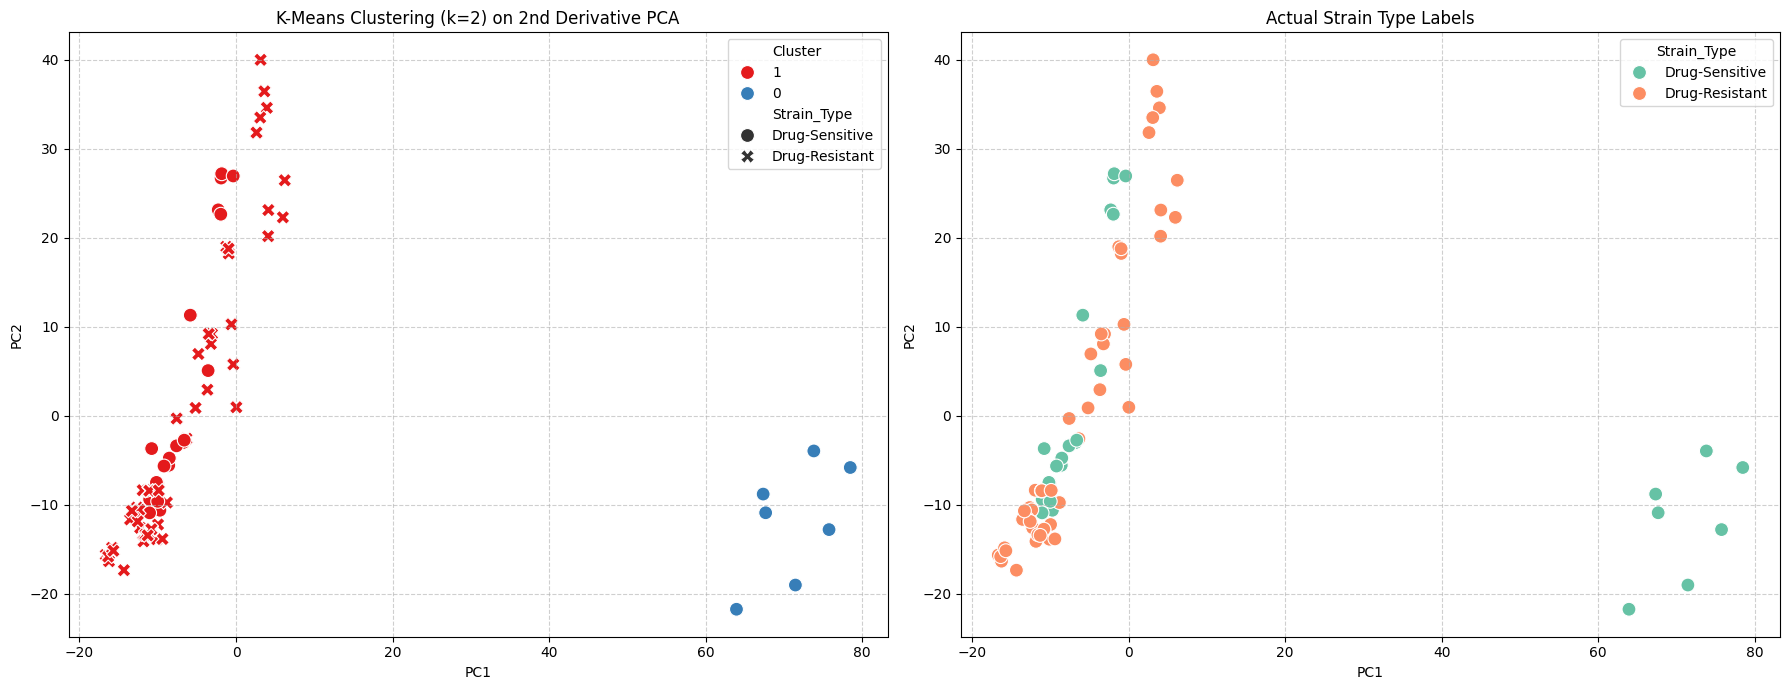

Cluster Composition by Strain Type:


Strain_Type,Drug-Resistant,Drug-Sensitive
Cluster,,
0,0,7
1,50,22


In [51]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Apply K-Means clustering
# We'll start with 2 clusters to see if they align with Resistant vs Sensitive
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca_2nd)

# 2. Add cluster labels to our PCA dataframe for visualization
pca_cluster_df = pd.DataFrame(data=X_pca_2nd[:, :2], columns=['PC1', 'PC2'])
pca_cluster_df['Cluster'] = clusters.astype(str)
pca_cluster_df['Strain_Type'] = y.values
pca_cluster_df['Species'] = df['Species_Name'].values

# 3. Visualize the clusters vs actual Strain Type
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot K-Means Clusters
sns.scatterplot(data=pca_cluster_df, x='PC1', y='PC2', hue='Cluster', style='Strain_Type', s=100, ax=ax1, palette='Set1')
ax1.set_title('K-Means Clustering (k=2) on 2nd Derivative PCA')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Actual Strain Types for comparison
sns.scatterplot(data=pca_cluster_df, x='PC1', y='PC2', hue='Strain_Type', s=100, ax=ax2, palette='Set2')
ax2.set_title('Actual Strain Type Labels')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. Analyze Cluster Composition
cluster_summary = pca_cluster_df.groupby(['Cluster', 'Strain_Type']).size().unstack(fill_value=0)
print("Cluster Composition by Strain Type:")
display(cluster_summary)

### Evaluating Cluster Alignment with Species

Since the k=2 clustering did not effectively separate strains by resistance, we will investigate if the clusters align with the biological species. We will also use the Silhouette score and the Elbow method to find the optimal number of clusters, which may correspond to the five species present in the dataset.

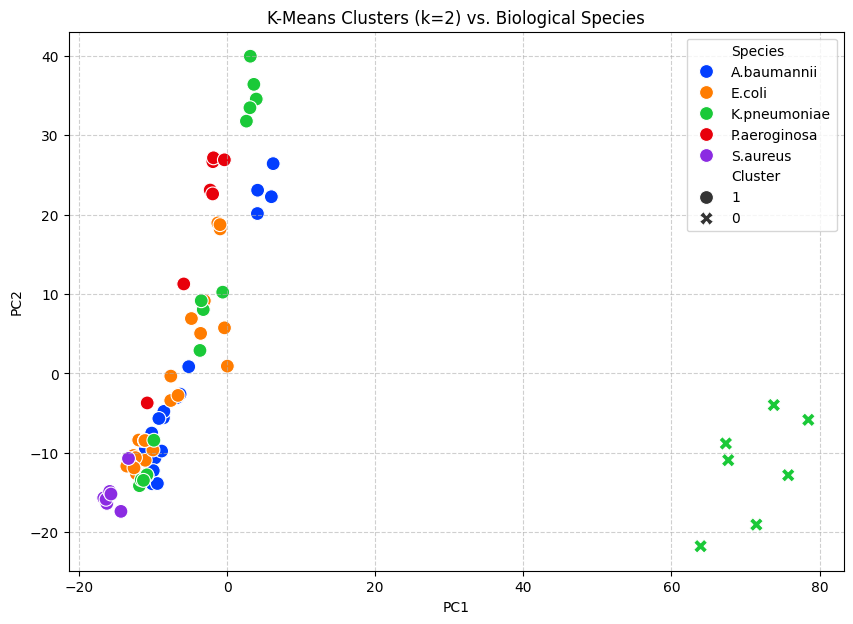

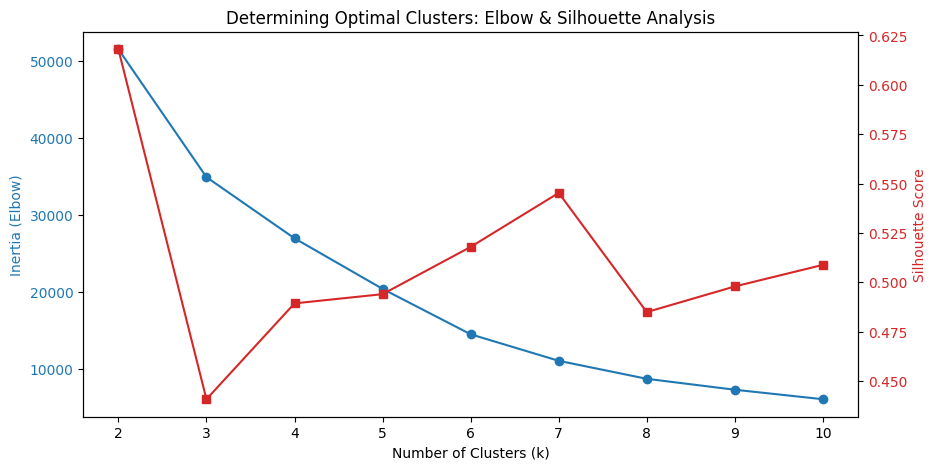

Cluster Composition by Species:


Species,A.baumannii,E.coli,K.pneumoniae,P.aeroginosa,S.aureus
Cluster,,,,,
0,0,0,7,0,0
1,20,23,15,7,7


In [52]:
from sklearn.metrics import silhouette_score

# 1. Visualize the current k=2 clusters with Species labels
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_cluster_df, x='PC1', y='PC2', hue='Species', style='Cluster', s=100, palette='bright')
plt.title('K-Means Clusters (k=2) vs. Biological Species')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Elbow Method and Silhouette Score to find optimal k
ss_scores = []
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca_2nd)
    ss_scores.append(silhouette_score(X_pca_2nd, labels))
    inertia.append(km.inertia_)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Elbow)', color='tab:blue')
ax1.plot(k_range, inertia, marker='o', color='tab:blue', label='Inertia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(k_range, ss_scores, marker='s', color='tab:red', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Determining Optimal Clusters: Elbow & Silhouette Analysis')
plt.show()

# 3. Crosstab of k=2 clusters vs Species
species_cluster_comp = pd.crosstab(pca_cluster_df['Cluster'], pca_cluster_df['Species'])
print("Cluster Composition by Species:")
display(species_cluster_comp)

### Interpreting PCA via Loadings (Chemical Mapping)

To understand the biochemical meaning of the PCs, we examine the 'loadings'. The peaks in the loading plots indicate the wavenumbers where the variance is highest. We will map these back to DNA-specific signatures:
*   **~1080 cm⁻¹**: PO$_2^-$ symmetric stretch (DNA backbone).
*   **~1240 cm⁻¹**: PO$_2^-$ asymmetric stretch (DNA backbone).
*   **~1600-1700 cm⁻¹**: Base pairing / Carbonyl stretching (G, C, A, T).

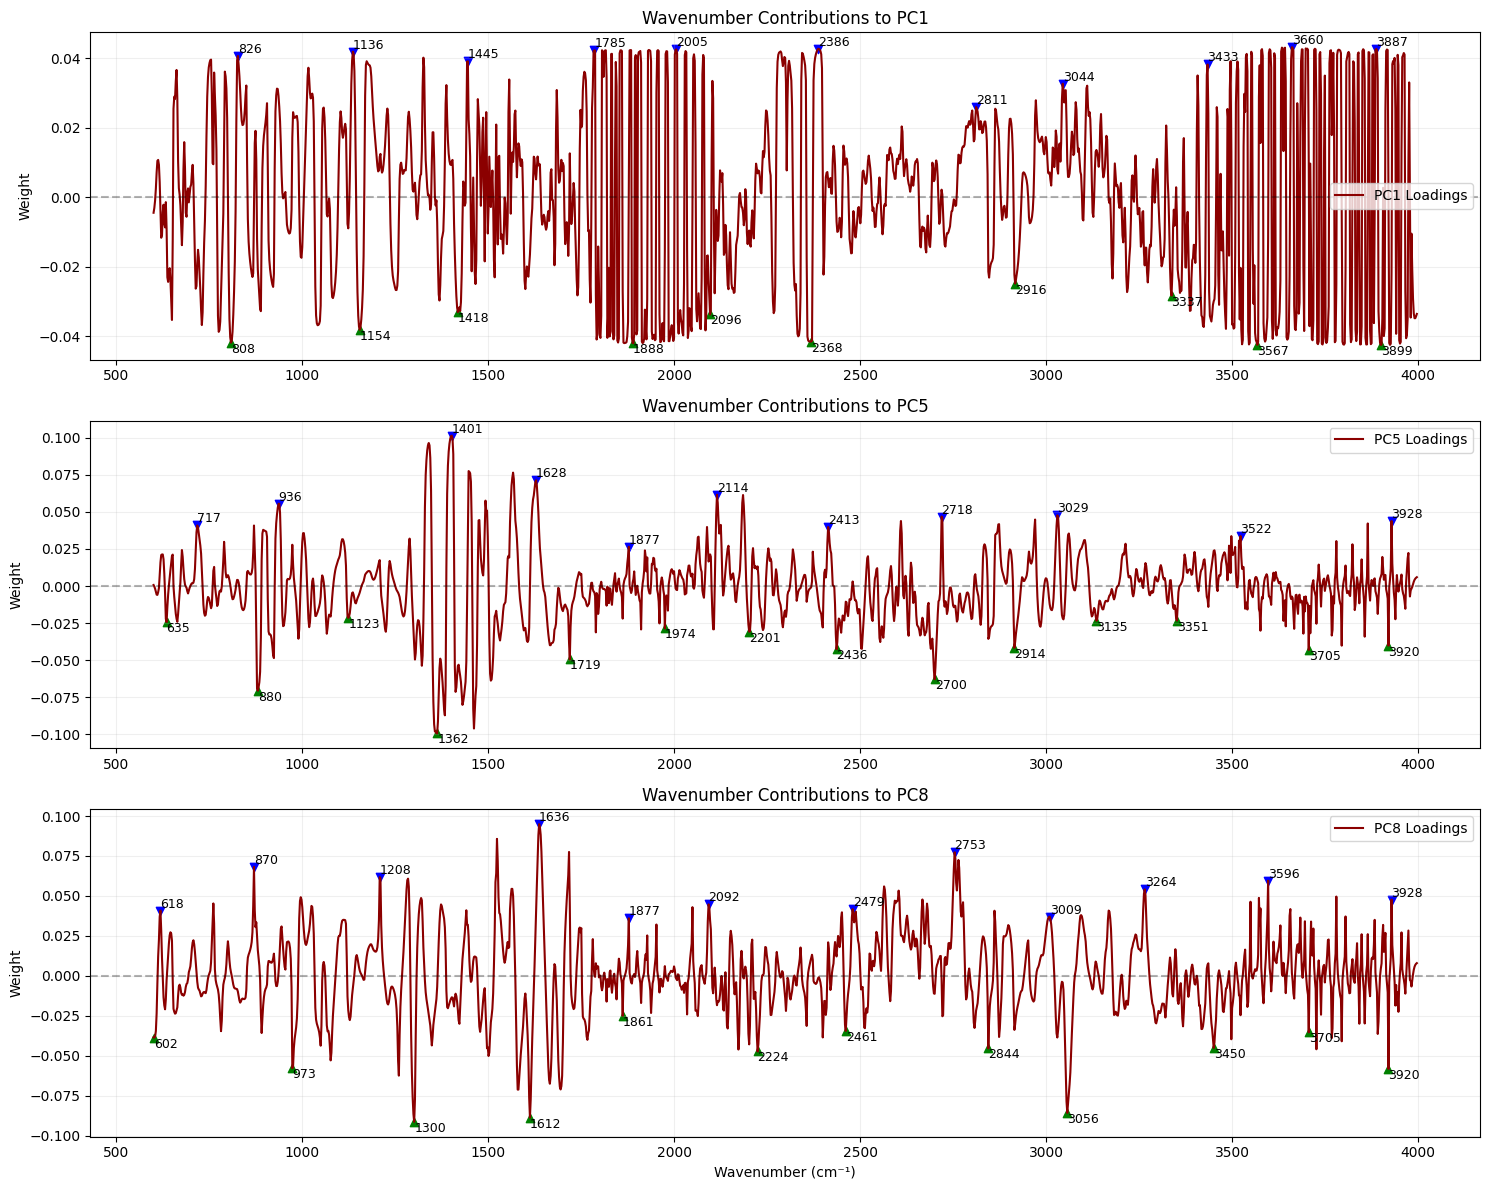

In [48]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

# Get loadings from the trained model
loadings = pca_species_95.components_
pcs_to_plot = [0, 4, 7] # PC1, PC5, PC8

plt.figure(figsize=(15, 12))

for i, pc_idx in enumerate(pcs_to_plot):
    pc_loadings = loadings[pc_idx]

    # Find top positive and negative peaks for interpretation
    pos_peaks, _ = find_peaks(pc_loadings, height=0.02, distance=100)
    neg_peaks, _ = find_peaks(-pc_loadings, height=0.02, distance=100)

    plt.subplot(3, 1, i+1)
    plt.plot(wavenumbers, pc_loadings, label=f'PC{pc_idx+1} Loadings', color='darkred')
    plt.scatter(wavenumbers[pos_peaks], pc_loadings[pos_peaks], color='blue', marker='v')
    plt.scatter(wavenumbers[neg_peaks], pc_loadings[neg_peaks], color='green', marker='^')

    # Annotate top peaks
    for p in pos_peaks:
        plt.text(wavenumbers[p], pc_loadings[p], f'{wavenumbers[p]:.0f}', fontsize=9, verticalalignment='bottom')
    for n in neg_peaks:
        plt.text(wavenumbers[n], pc_loadings[n], f'{wavenumbers[n]:.0f}', fontsize=9, verticalalignment='top')

    plt.axhline(0, color='black', linestyle='--', alpha=0.3)
    plt.title(f'Wavenumber Contributions to PC{pc_idx+1}')
    plt.ylabel('Weight')
    plt.grid(True, alpha=0.2)
    if i == 2: plt.xlabel('Wavenumber (cm⁻¹)')
    plt.legend()

plt.tight_layout()
plt.show()

### Biochemical Profiling: DNA Base Pairs by Species

Specific Raman bands correspond to different DNA bases:
*   **~1660-1670 cm⁻¹**: Thymine (T) and Guanine (G) C=O stretching.
*   **~1600-1630 cm⁻¹**: Adenine (A) and Cytosine (C) ring vibrations.
*   **~1575 cm⁻¹**: Guanine (G) and Adenine (A) ring vibrations.

We will compare these regions across the identified species.

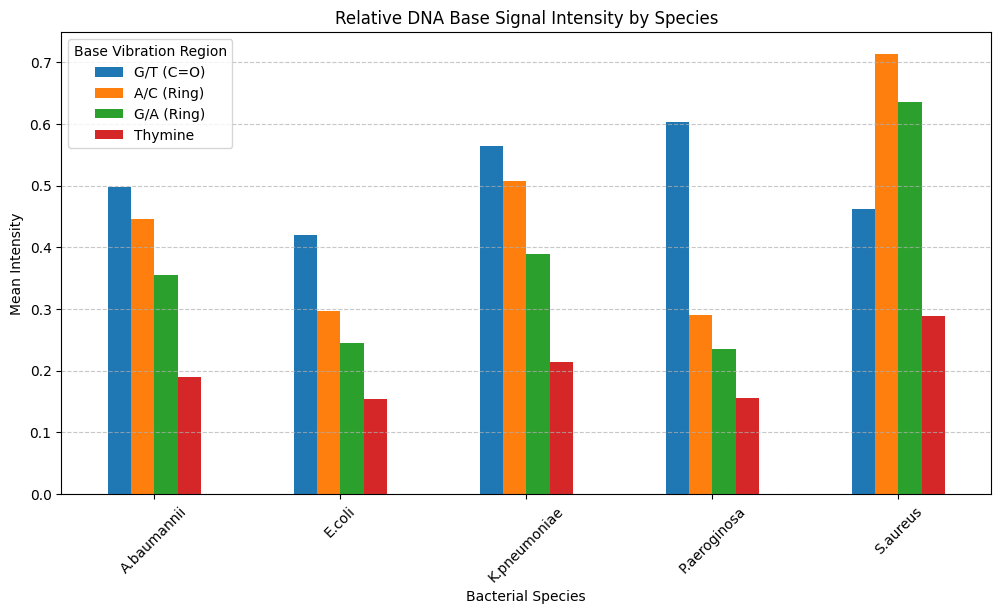

,G/T (C=O),A/C (Ring),G/A (Ring),Thymine
Species_Name,,,,
A.baumannii,0.497675,0.446002,0.354830,0.189752
E.coli,0.419083,0.296506,0.244757,0.154400
K.pneumoniae,0.564058,0.506721,0.389336,0.213902
P.aeroginosa,0.603764,0.290276,0.235770,0.156507
S.aureus,0.462686,0.712983,0.635931,0.288351


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define known wavenumbers for base pairs (based on literature)
base_markers = {
    'G/T (C=O)': 1665,
    'A/C (Ring)': 1610,
    'G/A (Ring)': 1575,
    'Thymine': 1485
}

# Find the actual columns closest to these markers
marker_cols = {}
for label, wn in base_markers.items():
    closest_col = df.columns[np.abs(pd.to_numeric(df.columns, errors='coerce') - wn).argmin()]
    marker_cols[label] = closest_col

# Extract mean intensities for each species at these markers
species_base_profile = df.groupby('Species_Name')[list(marker_cols.values())].mean()
species_base_profile.columns = list(marker_cols.keys())

# Plotting the comparison
species_base_profile.plot(kind='bar', figsize=(12, 6))
plt.title('Relative DNA Base Signal Intensity by Species')
plt.ylabel('Mean Intensity')
plt.xlabel('Bacterial Species')
plt.xticks(rotation=45)
plt.legend(title='Base Vibration Region')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

display(species_base_profile)

### DNA Base Signal Intensity: Species vs. Drug Sensitivity

We will now compare the relative intensities of key DNA markers across species, further subdivided by their drug-resistance status. This allows us to see if resistance mechanisms significantly alter the spectral representation of genomic content.

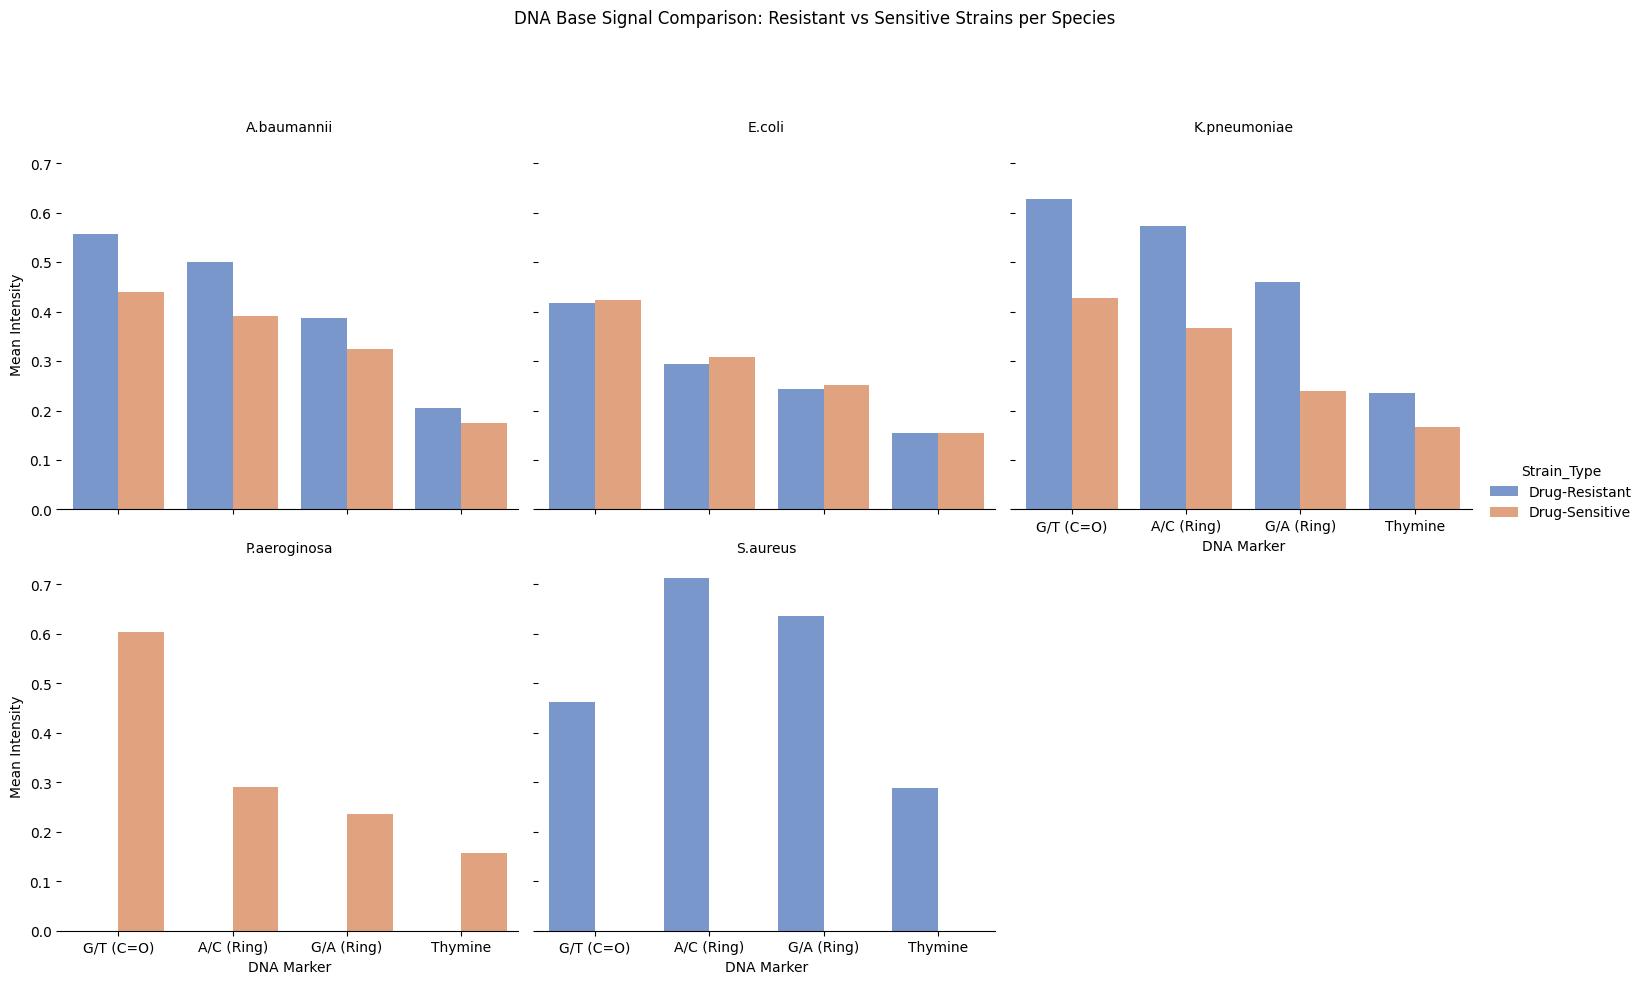

,Species_Name,Strain_Type,1665.19,1609.55,1574.51,1485.89
0,A.baumannii,Drug-Resistant,0.556365,0.500168,0.386209,0.205580
1,A.baumannii,Drug-Sensitive,0.438984,0.391836,0.323452,0.173924
2,E.coli,Drug-Resistant,0.417693,0.293273,0.243129,0.154472
3,E.coli,Drug-Sensitive,0.424088,0.308142,0.250618,0.154142
4,K.pneumoniae,Drug-Resistant,0.628267,0.572267,0.459590,0.235678
5,K.pneumoniae,Drug-Sensitive,0.426467,0.366267,0.238793,0.167239
6,P.aeroginosa,Drug-Sensitive,0.603764,0.290276,0.235770,0.156507
7,S.aureus,Drug-Resistant,0.462686,0.712983,0.635931,0.288351


In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Extract mean intensities grouped by Species and Strain Type
columns_to_extract = list(marker_cols.values())
grouped_data = df.groupby(['Species_Name', 'Strain_Type'])[columns_to_extract].mean().reset_index()

# 2. Melt the dataframe for easier plotting with Seaborn
melted_df = grouped_data.melt(id_vars=['Species_Name', 'Strain_Type'],
                              value_vars=columns_to_extract,
                              var_name='Marker_Wavenumber',
                              value_name='Intensity')

# Map the actual column names back to their human-readable labels
inv_marker_cols = {v: k for k, v in marker_cols.items()}
melted_df['Marker_Label'] = melted_df['Marker_Wavenumber'].map(inv_marker_cols)

# 3. Visualization
g = sns.catplot(
    data=melted_df, kind="bar",
    x="Marker_Label", y="Intensity", hue="Strain_Type",
    col="Species_Name", col_wrap=3,
    palette="muted", alpha=.8, height=5, aspect=1
)

g.set_axis_labels("DNA Marker", "Mean Intensity")
g.set_titles("{col_name}")
g.despine(left=True)
plt.subplots_adjust(top=0.85)
g.fig.suptitle('DNA Base Signal Comparison: Resistant vs Sensitive Strains per Species')

plt.show()

# Display the numerical summary
display(grouped_data)

### Within-Species Spectral Comparison: Resistant vs. Sensitive

We will now visualize the average Raman spectrum for each species, split by resistance status. This allows us to observe local spectral shifts that might be obscured when looking at the entire dataset at once.

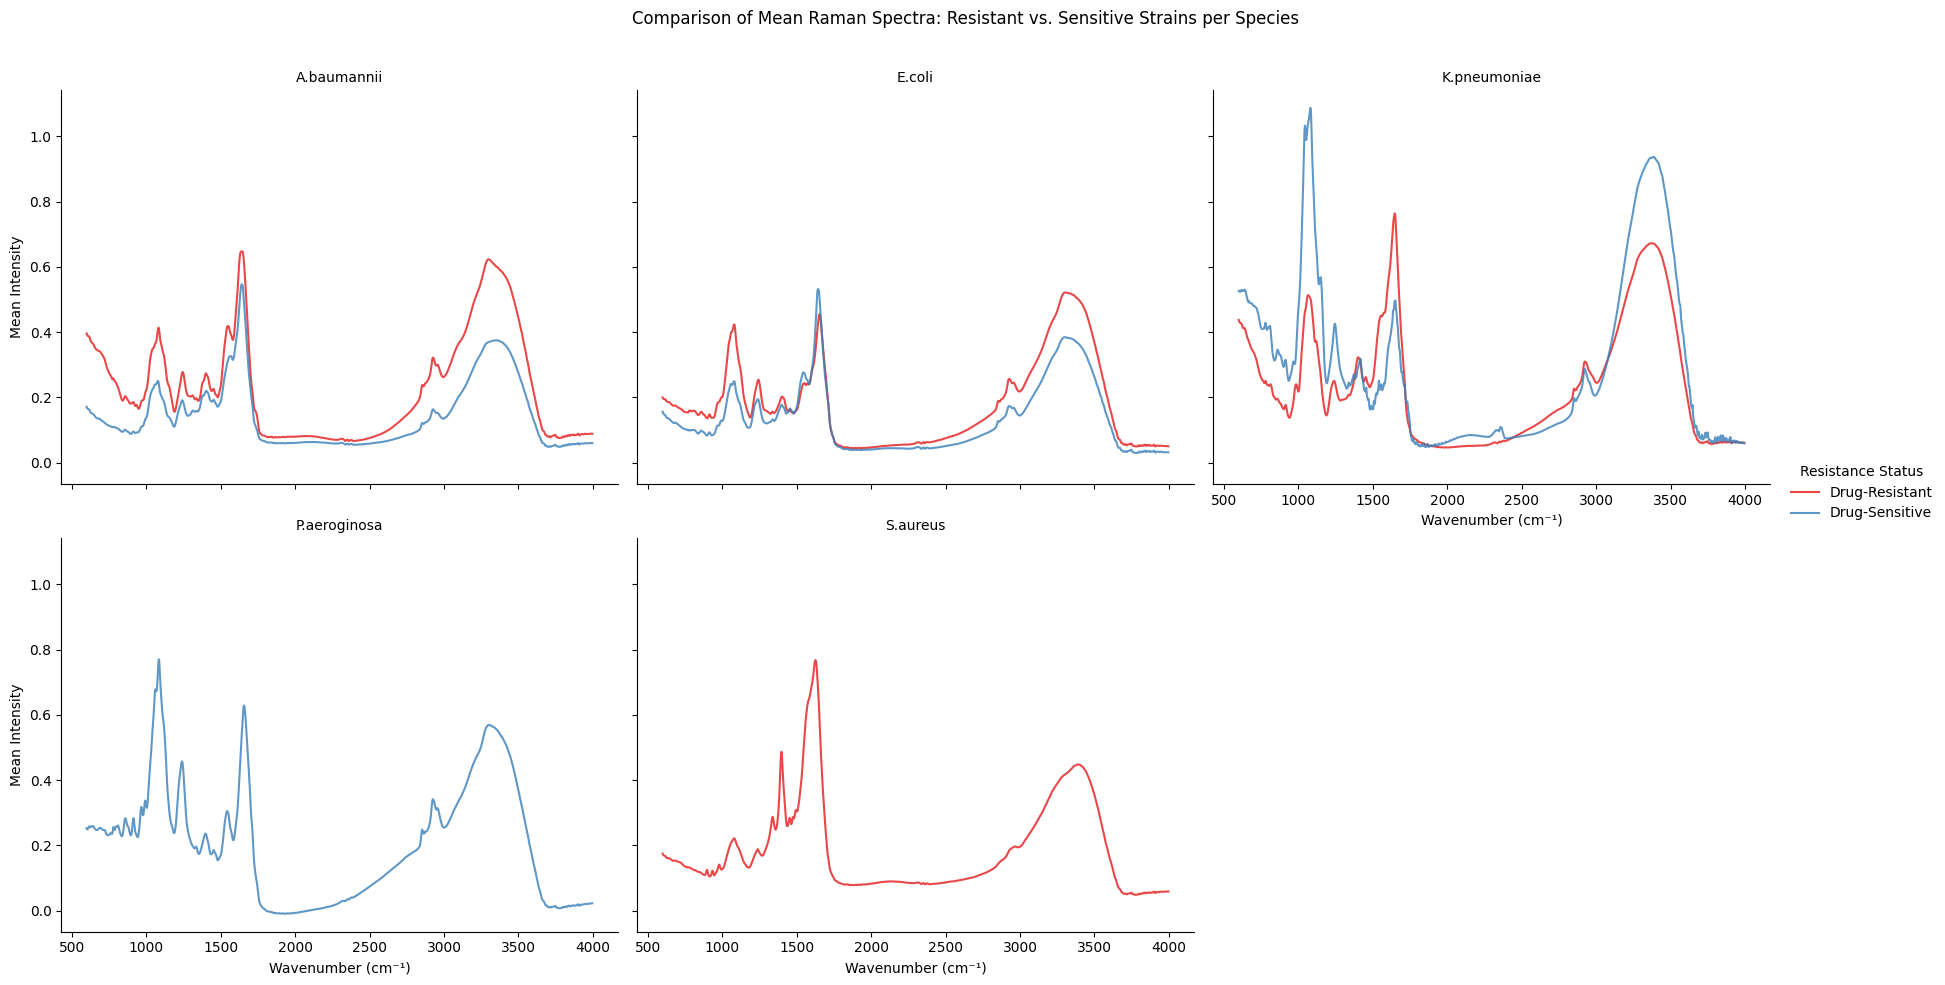

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate mean spectra grouped by Species and Strain Type
species_strain_means = df.groupby(['Species_Name', 'Strain_Type'])[spectral_columns].mean().reset_index()

# 2. Melt the dataframe for plotting
melted_spectra = species_strain_means.melt(id_vars=['Species_Name', 'Strain_Type'],
                                           var_name='Wavenumber',
                                           value_name='Mean_Intensity')

# Ensure Wavenumber is numeric for proper scaling on the X-axis
melted_spectra['Wavenumber'] = pd.to_numeric(melted_spectra['Wavenumber'])

# 3. Create faceted line plots
g = sns.FacetGrid(melted_spectra, col="Species_Name", hue="Strain_Type",
                  col_wrap=3, height=5, aspect=1.2, palette='Set1')

g.map(sns.lineplot, "Wavenumber", "Mean_Intensity", alpha=0.8)

g.add_legend(title="Resistance Status")
g.set_titles("{col_name}")
g.set_axis_labels("Wavenumber (cm⁻¹)", "Mean Intensity")

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Comparison of Mean Raman Spectra: Resistant vs. Sensitive Strains per Species')

plt.show()

### PCA on Smoothed Spectral Data

We will now re-run the PCA analysis using the smoothed spectral features to see if the reduction in noise provides a clearer low-dimensional representation of the data.

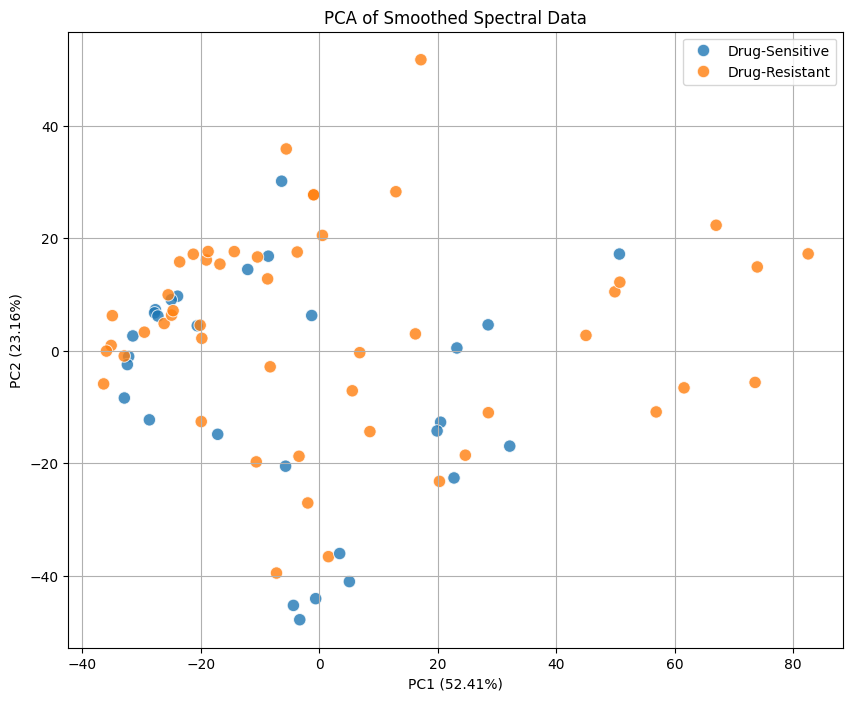

Explained variance ratio by first two components (Smoothed): 75.57%


In [32]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Prepare features from the smoothed dataframe
X_smooth = df_smoothed[spectral_columns]

# 2. Standardize the smoothed data
scaler_smooth = StandardScaler()
X_smooth_scaled = scaler_smooth.fit_transform(X_smooth)

# 3. Perform PCA with 2 components
pca_smooth = PCA(n_components=2)
principal_components_smooth = pca_smooth.fit_transform(X_smooth_scaled)

# 4. Create a DataFrame for visualization
pca_smooth_df = pd.DataFrame(data=principal_components_smooth, columns=['PC1 (Smoothed)', 'PC2 (Smoothed)'])
pca_smooth_df['Strain_Type'] = df_smoothed['Strain_Type'].values

# 5. Plotting
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1 (Smoothed)',
    y='PC2 (Smoothed)',
    hue='Strain_Type',
    data=pca_smooth_df,
    s=80,
    alpha=0.8
)

plt.title('PCA of Smoothed Spectral Data')
plt.xlabel(f'PC1 ({pca_smooth.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca_smooth.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.legend()
plt.show()

print(f"Explained variance ratio by first two components (Smoothed): {pca_smooth.explained_variance_ratio_.sum()*100:.2f}%")

### Train a Classifier using Principal Components

Now, we'll use the `num_components_95` (which is 6) principal components as features to train a classification model. This will demonstrate how well the reduced-dimensionality data can differentiate between the two strain types.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Re-perform PCA with the optimal number of components (6)
pca_optimal = PCA(n_components=num_components_95)
X_pca = pca_optimal.fit_transform(X_scaled)

print(f"Shape of data after PCA with {num_components_95} components: {X_pca.shape}")


Shape of data after PCA with 6 components: (79, 6)


In [13]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")


Training set size: 55
Testing set size: 24


In [14]:
# Initialize and train a Logistic Regression classifier
classifier = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' for small datasets and binary classification
classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = classifier.predict(X_test)

# Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Classifier Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)


Classifier Accuracy: 0.6667

Classification Report:
                precision    recall  f1-score   support

Drug-Resistant       0.62      1.00      0.76        13
Drug-Sensitive       1.00      0.27      0.43        11

      accuracy                           0.67        24
     macro avg       0.81      0.64      0.60        24
  weighted avg       0.79      0.67      0.61        24



In [15]:
print("Class distribution in the training set:")
display(y_train.value_counts())

Class distribution in the training set:


,count
Strain_Type,
Drug-Resistant,37
Drug-Sensitive,18


In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
display(y_train_resampled.value_counts())

Class distribution after SMOTE:


,count
Strain_Type,
Drug-Resistant,37
Drug-Sensitive,37


### Retrain Classifier with Balanced Data

In [17]:
# Initialize and train a new Logistic Regression classifier with the resampled data
classifier_resampled = LogisticRegression(random_state=42, solver='liblinear')
classifier_resampled.fit(X_train_resampled, y_train_resampled)

# Make predictions on the original test set
y_pred_resampled = classifier_resampled.predict(X_test)

# Evaluate the classifier
accuracy_resampled = accuracy_score(y_test, y_pred_resampled)
report_resampled = classification_report(y_test, y_pred_resampled)

print(f"Classifier Accuracy (after SMOTE): {accuracy_resampled:.4f}")
print("\nClassification Report (after SMOTE):")
print(report_resampled)

Classifier Accuracy (after SMOTE): 0.6667

Classification Report (after SMOTE):
                precision    recall  f1-score   support

Drug-Resistant       0.69      0.69      0.69        13
Drug-Sensitive       0.64      0.64      0.64        11

      accuracy                           0.67        24
     macro avg       0.66      0.66      0.66        24
  weighted avg       0.67      0.67      0.67        24



### Retrain Classifier with Random Forest on Balanced Data

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train a Random Forest classifier with the resampled data
random_forest_classifier = RandomForestClassifier(random_state=42)
random_forest_classifier.fit(X_train_resampled, y_train_resampled)

# Make predictions on the original test set
y_pred_rf = random_forest_classifier.predict(X_test)

# Evaluate the classifier
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

print(f"Random Forest Classifier Accuracy (after SMOTE): {accuracy_rf:.4f}")
print("\nRandom Forest Classification Report (after SMOTE):")
print(report_rf)

Random Forest Classifier Accuracy (after SMOTE): 0.7083

Random Forest Classification Report (after SMOTE):
                precision    recall  f1-score   support

Drug-Resistant       0.69      0.85      0.76        13
Drug-Sensitive       0.75      0.55      0.63        11

      accuracy                           0.71        24
     macro avg       0.72      0.70      0.70        24
  weighted avg       0.72      0.71      0.70        24



### Hyperparameter Tuning for Random Forest

We will use `GridSearchCV` to explore different hyperparameters for the Random Forest model to optimize its predictive performance on the balanced dataset.

In [21]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize the Random Forest classifier
rf = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=1, scoring='accuracy')

# Fit the grid search to the resampled training data
grid_search.fit(X_train_resampled, y_train_resampled)

# Get the best parameters and the best model
best_params = grid_search.best_params_
best_rf_model = grid_search.best_estimator_

print(f"Best Parameters: {best_params}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Parameters: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [22]:
# Evaluate the tuned model on the original test set
y_pred_tuned = best_rf_model.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
report_tuned = classification_report(y_test, y_pred_tuned)

print(f"Tuned Random Forest Accuracy: {accuracy_tuned:.4f}")
print("\nTuned Random Forest Classification Report:")
print(report_tuned)

Tuned Random Forest Accuracy: 0.7083

Tuned Random Forest Classification Report:
                precision    recall  f1-score   support

Drug-Resistant       0.69      0.85      0.76        13
Drug-Sensitive       0.75      0.55      0.63        11

      accuracy                           0.71        24
     macro avg       0.72      0.70      0.70        24
  weighted avg       0.72      0.71      0.70        24



### Keras Neural Network with Small, Balanced Training Data

In [19]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report

# 1. Label Encode the target variable (Strain_Type)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y) # Converts 'Drug-Resistant' and 'Drug-Sensitive' to 0 and 1

# 2. Create a small, balanced training set (24 samples: 12 Drug-Resistant, 12 Drug-Sensitive)
#    and a validation set from the remaining data.

# Identify indices for each strain type
drug_resistant_indices = np.where(y == 'Drug-Resistant')[0]
drug_sensitive_indices = np.where(y == 'Drug-Sensitive')[0]

# Randomly sample 12 from each for the small training set
np.random.seed(42) # for reproducibility
train_dr_indices = np.random.choice(drug_resistant_indices, 12, replace=False)
train_ds_indices = np.random.choice(drug_sensitive_indices, 12, replace=False)

train_small_indices = np.concatenate([train_dr_indices, train_ds_indices])
np.random.shuffle(train_small_indices) # Shuffle to mix classes

X_train_small = X_pca[train_small_indices]
y_train_small_encoded = y_encoded[train_small_indices]

# The remaining data for validation
all_indices = np.arange(len(X_pca))
val_indices = np.setdiff1d(all_indices, train_small_indices)

X_val = X_pca[val_indices]
y_val_encoded = y_encoded[val_indices]

print(f"Shape of small training features: {X_train_small.shape}")
print(f"Shape of small training labels: {y_train_small_encoded.shape}")
print(f"Shape of validation features: {X_val.shape}")
print(f"Shape of validation labels: {y_val_encoded.shape}")
print(f"\nClass distribution in small training set: {label_encoder.inverse_transform(np.unique(y_train_small_encoded))}: {np.unique(y_train_small_encoded, return_counts=True)[1]}")
print(f"Class distribution in validation set: {label_encoder.inverse_transform(np.unique(y_val_encoded))}: {np.unique(y_val_encoded, return_counts=True)[1]}")

Shape of small training features: (24, 6)
Shape of small training labels: (24,)
Shape of validation features: (55, 6)
Shape of validation labels: (55,)

Class distribution in small training set: ['Drug-Resistant' 'Drug-Sensitive']: [12 12]
Class distribution in validation set: ['Drug-Resistant' 'Drug-Sensitive']: [38 17]


### Build and Train the Keras Model

In [20]:
# 3. Build the Keras model
num_features = X_train_small.shape[1] # This will be 6 from PCA

model = keras.Sequential([
    layers.Input(shape=(num_features,)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid') # Binary classification
])

# 4. Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Model Summary:")
model.summary()

# 5. Train the model
history = model.fit(X_train_small, y_train_small_encoded,
                    epochs=50, # Train for 50 epochs
                    batch_size=8, # Small batch size for small dataset
                    validation_data=(X_val, y_val_encoded),
                    verbose=0) # Set to 1 or 2 to see training progress

# 6. Evaluate the model on the validation data
loss, accuracy = model.evaluate(X_val, y_val_encoded, verbose=0)
print(f"\nValidation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# Get predictions and classification report
y_pred_nn = (model.predict(X_val) > 0.5).astype("int32")
print("\nClassification Report for Neural Network (on validation set):")
print(classification_report(y_val_encoded, y_pred_nn, target_names=label_encoder.classes_))

Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)


Validation Loss: 0.8335
Validation Accuracy: 0.5636
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

Classification Report for Neural Network (on validation set):
                precision    recall  f1-score   support

Drug-Resistant       0.82      0.47      0.60        38
Drug-Sensitive       0.39      0.76      0.52        17

      accuracy                           0.56        55
     macro avg       0.61      0.62      0.56        55
  weighted avg       0.69      0.56      0.58        55

